# 강희실록 위기 예측 분석
> **파일 준비**: `kangxi_master_A_preprocessed.csv` 와 `kangxi_master_A_1661_1722.csv`를 같은 폴더에 두세요.

### ⚠️ 100% 정확도 방지를 위한 설계 원칙
| 문제 | 원인 | 해결 |
|------|------|------|
| 데이터 리키지 | `희귀단어(양)/(음)` = 전체 데이터로 위기와 상관 후 파생 | 두 컬럼 제거 |
| p ≫ n | 특성 2,697개 vs 샘플 62개 → 완전분리 trivial | MODEL1: Top-50만 사용, MODEL2·3: PCA 20차원 |
| 훈련셋 정확도 | 항상 100% → 의미 없음 | 모든 모델 **LOO-CV 정확도**만 보고 |

## ✅ 공통 설정 & 데이터 로드  ← 먼저 실행

In [35]:
# ============================================================
# 공통 설정 & 데이터 로드
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.linear_model    import LogisticRegression, LassoCV, Lasso
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_score, StratifiedKFold
from sklearn.decomposition   import PCA
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics         import accuracy_score, classification_report
from sklearn.pipeline        import Pipeline

# ── 한글 폰트 ────────────────────────────────────────────────
import platform, os
if platform.system() == "Linux":
    os.system("apt-get install -y fonts-nanum > /dev/null 2>&1")
    fm._load_fontmanager(try_read_cache=False)
    nanum = [f for f in fm.findSystemFonts() if "Nanum" in f]
    plt.rcParams["font.family"] = fm.FontProperties(fname=nanum[0]).get_name() if nanum else "DejaVu Sans"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ── 데이터 로드 ──────────────────────────────────────────────
DATA_PATH = "kangxi_master_A_preprocessed.csv"   # ← 경로 수정
df_raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig", index_col=0)
df_raw.index = df_raw.index.astype(str)

y_raw = df_raw["위기"].values.astype(int)
y_bin = (y_raw >= 1).astype(int)          # 이진 타깃: 위기월 1개 이상 → 1

# ── 리키지 방지: 희귀단어(양)/(음) 제거 ─────────────────────
# 이 두 컬럼은 전체 데이터로 위기와 상관 계산 후 파생 → 데이터 리키지
X_full = df_raw.drop(columns=["위기", "희귀 단어 (양)", "희귀 단어 (음)"]).astype(float)

print(f"데이터 shape  : {df_raw.shape}")
print(f"특성 shape    : {X_full.shape}  (리키지 컬럼 2개 제거 후)")
print(f"위기=0 연도   : {(y_bin==0).sum()}개  |  위기=1 연도 : {(y_bin==1).sum()}개")
print()
print("⚠️  n=62, p≫n 문제로 인해 모든 모델은 LOO-CV(Leave-One-Out) 정확도를 사용합니다.")
print("   (훈련셋 정확도 = 고차원 완전분리로 항상 100% → 의미 없음)")
print("\n공통 설정 완료 ✅")


데이터 shape  : (62, 2698)
특성 shape    : (62, 2695)  (리키지 컬럼 2개 제거 후)
위기=0 연도   : 34개  |  위기=1 연도 : 28개

⚠️  n=62, p≫n 문제로 인해 모든 모델은 LOO-CV(Leave-One-Out) 정확도를 사용합니다.
   (훈련셋 정확도 = 고차원 완전분리로 항상 100% → 의미 없음)

공통 설정 완료 ✅


---
## 🔵 MODEL 1 — 원본 Top-50 특성 | COR 히트맵 + Logistic & Lasso (LOO-CV)

Top-50 특성 선택 완료  (전체 2695개 중)


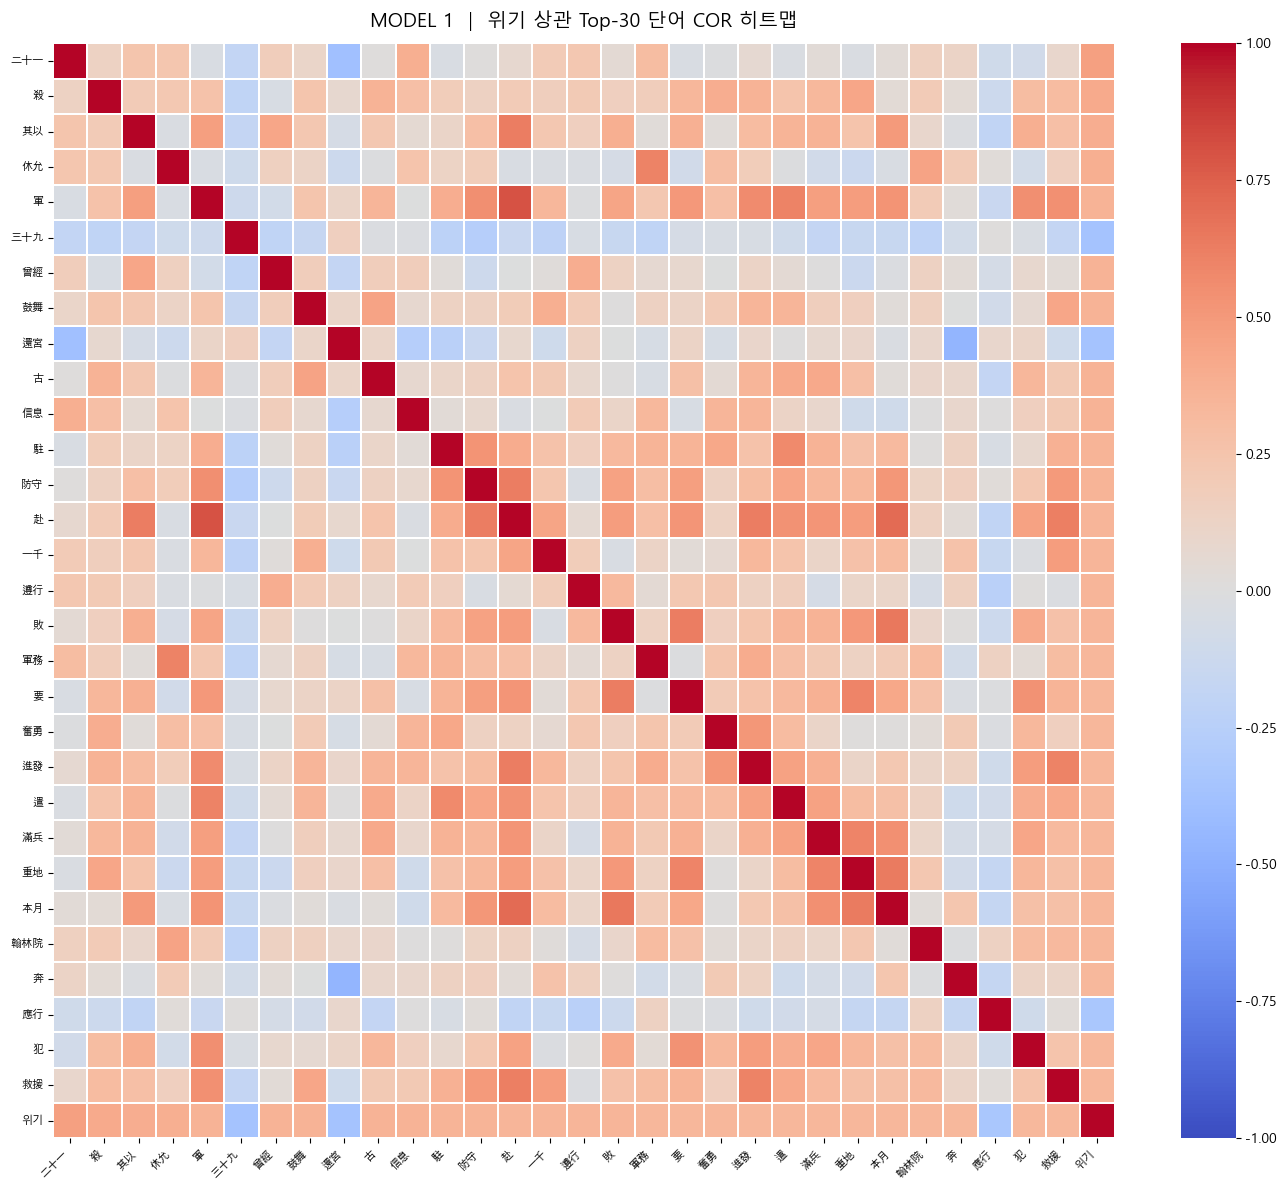

히트맵 저장 → model1_cor_heatmap.png

─── MODEL 1 │ Logistic Regression ───────────────────
  LOO-CV Accuracy : 0.9194 ± 0.2723
  (chance level   : 0.5484)

  중요 단어 Top-15 (|계수| 기준):
    ▲ 二十一              +0.2223
    ▼ 還宮               -0.2171
    ▲ 休允               +0.1906
    ▼ 應行               -0.1875
    ▲ 人心               +0.1749
    ▼ 百姓               -0.1594
    ▲ 達賴               +0.1516
    ▲ 殺                +0.1498
    ▼ 三十九              -0.1455
    ▲ 曾經               +0.1441
    ▲ 翰林院              +0.1436
    ▲ 鼓舞               +0.1424
    ▲ 朱                +0.1321
    ▼ 城隍               -0.1305
    ▲ 今聞               +0.1294

─── MODEL 1 │ Lasso ──────────────────────────────────
  Best Alpha      : 0.018847
  LOO-CV Accuracy : 0.8548
  비-0 계수       : 26개 선택됨

  중요 단어 Top-15 (|Lasso 계수| 기준):
    ▲ 達賴               +0.1210
    ▼ 還宮               -0.1171
    ▲ 休允               +0.1034
    ▲ 要                +0.0876
    ▲ 人心               +0.0703
    ▲ 鼓舞               +0.0692
 

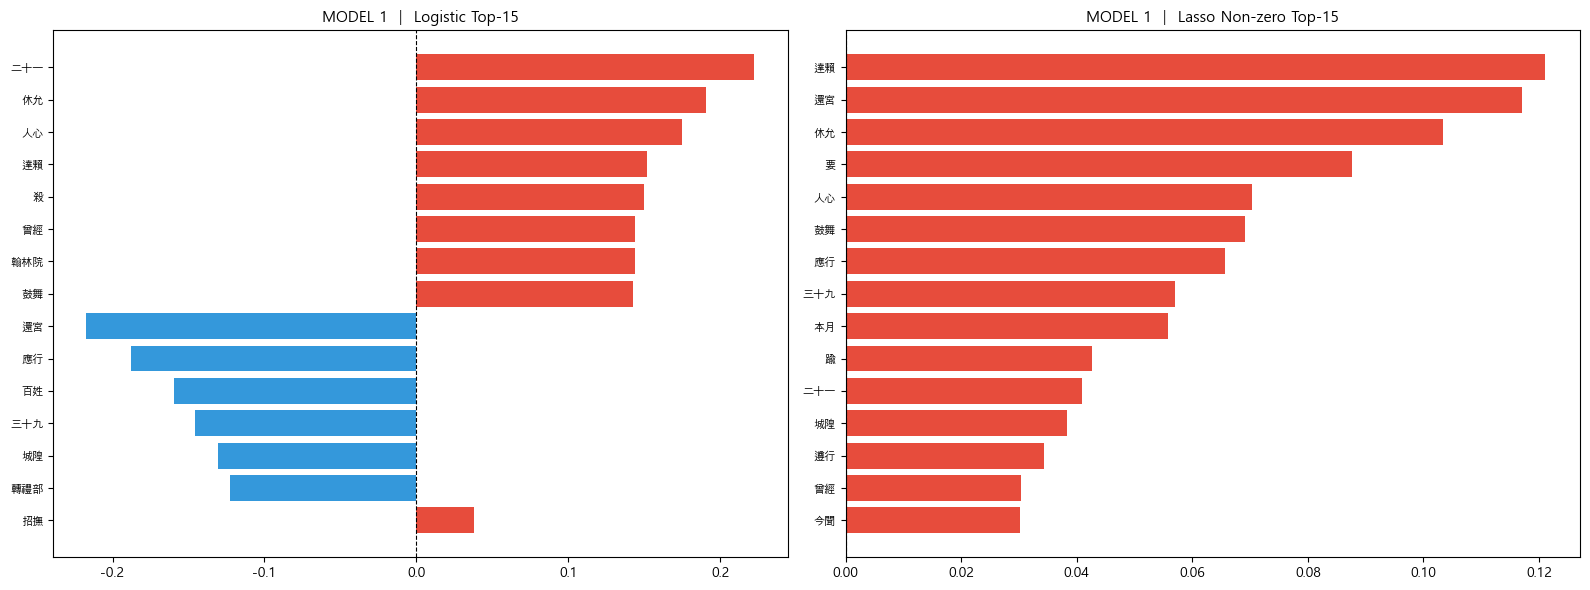

계수 차트 저장 → model1_coef.png


In [36]:
# ============================================================
# MODEL 1 ─ 원본 데이터 (Top-K 특성 선택)
#           COR 히트맵  +  Logistic(LOO-CV)  +  Lasso(LOO-CV)
# ============================================================

TOP_K = 50   # ← 위기 상관 상위 K개만 사용 (p≫n 방지)
LOO   = LeaveOneOut()

# ── (A) 스케일링 & Top-K 특성 선택 ─────────────────────────
scaler1 = StandardScaler()
X1_all  = pd.DataFrame(
    scaler1.fit_transform(X_full),
    columns=X_full.columns, index=X_full.index
)
# 위기와 절댓값 상관 상위 TOP_K 선택
corr_with_y = X1_all.corrwith(pd.Series(y_bin.astype(float), index=X1_all.index))
top_k_cols  = corr_with_y.abs().nlargest(TOP_K).index
X1 = X1_all[top_k_cols]

print(f"Top-{TOP_K} 특성 선택 완료  (전체 {X_full.shape[1]}개 중)")

# ── (B) COR 히트맵 (Top-30 + 위기) ─────────────────────────
top30 = corr_with_y.abs().nlargest(30).index
corr_top = X1_all[top30].copy()
corr_top["위기"] = y_bin.astype(float)
corr_mat1 = corr_top.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_mat1, annot=False, cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax)
ax.set_title(f"MODEL 1 │ 위기 상관 Top-30 단어 COR 히트맵", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("model1_cor_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("히트맵 저장 → model1_cor_heatmap.png")

# ── (C) Logistic Regression (LOO-CV) ────────────────────────
lr1 = LogisticRegression(
    penalty="l2", C=0.05, max_iter=3000,
    class_weight="balanced", solver="lbfgs", random_state=42
)
lr1_loo   = cross_val_score(lr1, X1, y_bin, cv=LOO, scoring="accuracy")
lr1.fit(X1, y_bin)
lr1_coef  = pd.Series(lr1.coef_[0], index=X1.columns)

print(f"\n─── MODEL 1 │ Logistic Regression ───────────────────")
print(f"  LOO-CV Accuracy : {lr1_loo.mean():.4f} ± {lr1_loo.std():.4f}")
print(f"  (chance level   : {max(y_bin.mean(), 1-y_bin.mean()):.4f})")
print(f"\n  중요 단어 Top-15 (|계수| 기준):")
for w, v in lr1_coef.abs().nlargest(15).items():
    sign = "▲" if lr1_coef[w] > 0 else "▼"
    print(f"    {sign} {w:15s}  {lr1_coef[w]:+.4f}")

# ── (D) Lasso (LOO-CV 정확도) ───────────────────────────────
lasso1_cv  = LassoCV(cv=5, max_iter=5000, random_state=42).fit(X1, y_bin.astype(float))
lasso1     = Lasso(alpha=lasso1_cv.alpha_, max_iter=5000).fit(X1, y_bin.astype(float))
lasso1_coef = pd.Series(lasso1.coef_, index=X1.columns)

# Lasso도 LOO-CV로 평가 (Pipeline으로 스케일 재적용 없이 이미 스케일됨)
def lasso_loo_acc(X, y, alpha):
    preds = []
    for train, test in LeaveOneOut().split(X):
        m = Lasso(alpha=alpha, max_iter=5000)
        m.fit(X[train], y[train])
        preds.append((m.predict(X[test])[0] >= 0.5).astype(int))
    return accuracy_score(y, preds)

lasso1_loo_acc = lasso_loo_acc(X1.values, y_bin.astype(float), lasso1_cv.alpha_)
nonzero1 = lasso1_coef[lasso1_coef != 0].abs().nlargest(15)

print(f"\n─── MODEL 1 │ Lasso ──────────────────────────────────")
print(f"  Best Alpha      : {lasso1_cv.alpha_:.6f}")
print(f"  LOO-CV Accuracy : {lasso1_loo_acc:.4f}")
print(f"  비-0 계수       : {(lasso1_coef != 0).sum()}개 선택됨")
print(f"\n  중요 단어 Top-15 (|Lasso 계수| 기준):")
for w, v in nonzero1.items():
    sign = "▲" if lasso1_coef[w] > 0 else "▼"
    print(f"    {sign} {w:15s}  {lasso1_coef[w]:+.4f}")

# ── (E) 계수 비교 바 차트 ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (title, coef) in zip(axes, [
        ("Logistic Top-15", pd.concat([lr1_coef.nlargest(8), lr1_coef.nsmallest(7)])),
        ("Lasso Non-zero Top-15", nonzero1 if len(nonzero1) >= 1 else pd.Series(dtype=float))
    ]):
    colors = ["#e74c3c" if v > 0 else "#3498db" for v in coef.values]
    ax.barh(coef.index[::-1], coef.values[::-1], color=colors[::-1])
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"MODEL 1 │ {title}", fontsize=11)
    ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("model1_coef.png", dpi=150, bbox_inches="tight")
plt.show()
print("계수 차트 저장 → model1_coef.png")

lr1_loo_mean   = lr1_loo.mean()
lasso1_loo_val = lasso1_loo_acc


---
## 🟢 MODEL 2 — TF-IDF + PCA(20) | COR 히트맵 + Logistic & Lasso (LOO-CV)

TF-IDF 변환 후 shape : (62, 2695)
PCA 20개 성분 누적 설명분산 : 50.2%


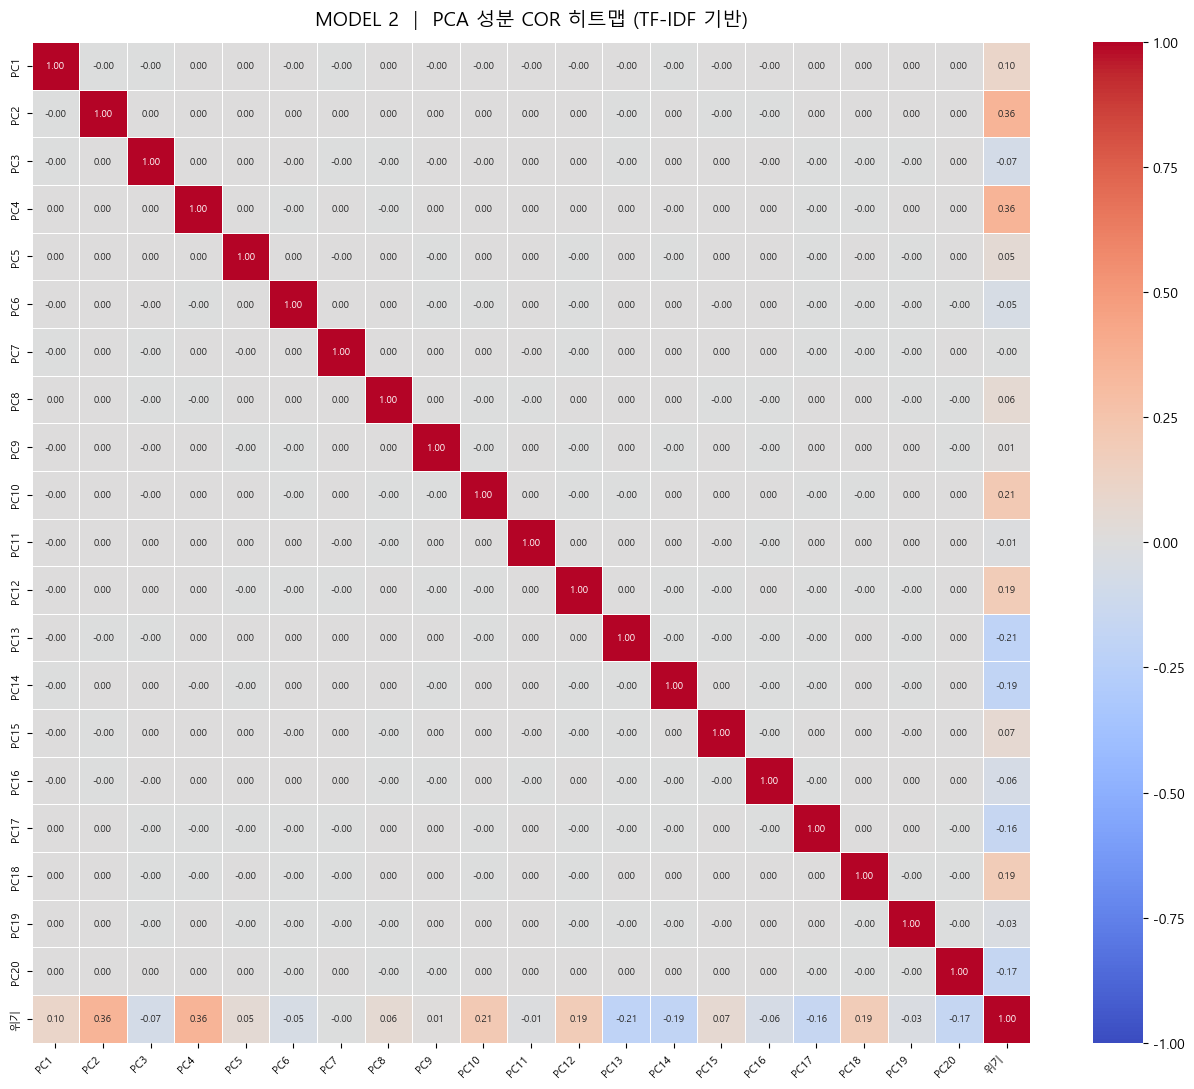

히트맵 저장 → model2_cor_heatmap.png


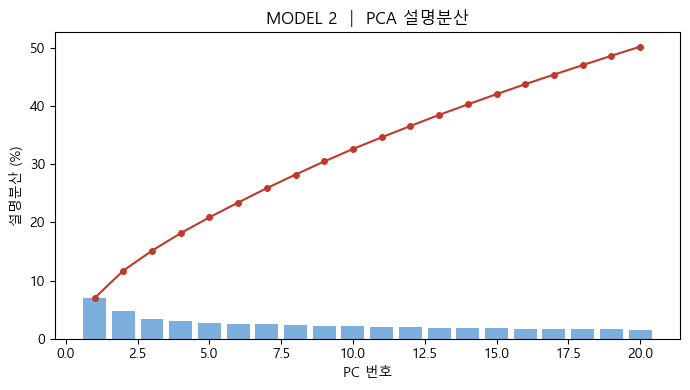


─── MODEL 2 │ Logistic Regression ───────────────────
  LOO-CV Accuracy : 0.6774 ± 0.4675
  PC 계수         : {'PC1': np.float64(0.404), 'PC2': np.float64(1.35), 'PC3': np.float64(-0.268), 'PC4': np.float64(1.239), 'PC5': np.float64(0.163), 'PC6': np.float64(-0.167), 'PC7': np.float64(-0.001), 'PC8': np.float64(0.173), 'PC9': np.float64(0.027), 'PC10': np.float64(0.664), 'PC11': np.float64(-0.029), 'PC12': np.float64(0.591), 'PC13': np.float64(-0.628), 'PC14': np.float64(-0.574), 'PC15': np.float64(0.196), 'PC16': np.float64(-0.174), 'PC17': np.float64(-0.471), 'PC18': np.float64(0.546), 'PC19': np.float64(-0.077), 'PC20': np.float64(-0.475)}

  위기 상관 상위 PC별 원단어 기여 Top-10:
    PC2: ['賊', '太皇太后', '大將', '官兵', '軍', '大兵', '赴', '皇太后', '岳州', '議敘']
    PC4: ['朕', '鰲', '隄', '喇嘛', '駐蹕', '罪', '拜', '皇太子', '二百', '引河']
    PC10: ['鰲', '拜', '罪', '朕', '班布爾善', '遏必隆', '乙巳', '布爾善', '丙午', '甲戌']

─── MODEL 2 │ Lasso ──────────────────────────────────
  Best Alpha      : 0.007062
  LOO-CV Accuracy : 0.6935


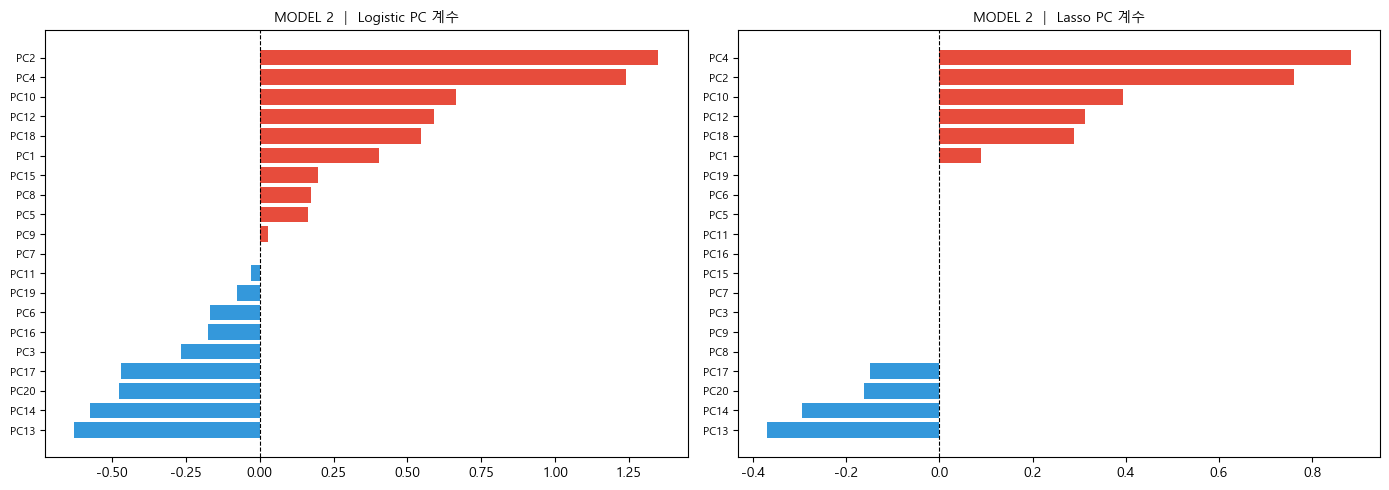

계수 차트 저장 → model2_coef.png


In [37]:
# ============================================================
# MODEL 2 ─ TF-IDF + PCA 차원축소
#           COR 히트맵  +  Logistic(LOO-CV)  +  Lasso(LOO-CV)
# ============================================================

LOO    = LeaveOneOut()
N_COMP = 20

# ── (A) TF-IDF 변환 ─────────────────────────────────────────
tfidf2      = TfidfTransformer(norm="l2", use_idf=True, smooth_idf=True)
X2_tfidf    = tfidf2.fit_transform(X_full.values)
X2_tfidf_df = pd.DataFrame(X2_tfidf.toarray(), columns=X_full.columns, index=X_full.index)
print(f"TF-IDF 변환 후 shape : {X2_tfidf_df.shape}")

# ── (B) PCA 차원축소 ─────────────────────────────────────────
pca2    = PCA(n_components=N_COMP, random_state=42)
X2_pca  = pca2.fit_transform(X2_tfidf_df)
exp_var = pca2.explained_variance_ratio_.cumsum()
print(f"PCA {N_COMP}개 성분 누적 설명분산 : {exp_var[-1]*100:.1f}%")

X2_pca_df = pd.DataFrame(
    X2_pca, columns=[f"PC{i+1}" for i in range(N_COMP)], index=X_full.index
)

# ── (C) COR 히트맵 ───────────────────────────────────────────
corr2     = X2_pca_df.copy()
corr2["위기"] = y_bin.astype(float)
corr_mat2 = corr2.corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_mat2, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.4, ax=ax, annot_kws={"size": 7})
ax.set_title("MODEL 2 │ PCA 성분 COR 히트맵 (TF-IDF 기반)", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("model2_cor_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("히트맵 저장 → model2_cor_heatmap.png")

# PCA 설명분산 차트
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, N_COMP+1), pca2.explained_variance_ratio_*100, color="#5b9bd5", alpha=0.8)
ax.plot(range(1, N_COMP+1), exp_var*100, "o-", color="#c0392b", lw=1.5, ms=4)
ax.set_xlabel("PC 번호"); ax.set_ylabel("설명분산 (%)")
ax.set_title("MODEL 2 │ PCA 설명분산")
plt.tight_layout()
plt.savefig("model2_pca_var.png", dpi=150, bbox_inches="tight")
plt.show()

# ── (D) Logistic Regression (LOO-CV) ────────────────────────
lr2 = LogisticRegression(
    penalty="l2", C=1.0, max_iter=3000,
    class_weight="balanced", random_state=42
)
lr2_loo  = cross_val_score(lr2, X2_pca_df, y_bin, cv=LOO, scoring="accuracy")
lr2.fit(X2_pca_df, y_bin)
lr2_coef = pd.Series(lr2.coef_[0], index=X2_pca_df.columns)

loadings2      = pd.DataFrame(pca2.components_,
                               index=X2_pca_df.columns, columns=X_full.columns)
top_pc_by_wigi = corr_mat2.drop(index="위기")["위기"].abs().nlargest(3).index.tolist()

print(f"\n─── MODEL 2 │ Logistic Regression ───────────────────")
print(f"  LOO-CV Accuracy : {lr2_loo.mean():.4f} ± {lr2_loo.std():.4f}")
print(f"  PC 계수         : {dict(zip(lr2_coef.index, lr2_coef.round(3).values))}")
print(f"\n  위기 상관 상위 PC별 원단어 기여 Top-10:")
for pc in top_pc_by_wigi:
    top_words = loadings2.loc[pc].abs().nlargest(10).index.tolist()
    print(f"    {pc}: {top_words}")

# ── (E) Lasso (LOO-CV) ───────────────────────────────────────
lasso2_cv  = LassoCV(cv=5, max_iter=5000, random_state=42).fit(X2_pca_df, y_bin.astype(float))
lasso2     = Lasso(alpha=lasso2_cv.alpha_, max_iter=5000).fit(X2_pca_df, y_bin.astype(float))
lasso2_coef = pd.Series(lasso2.coef_, index=X2_pca_df.columns)

def lasso_loo_acc(X, y, alpha):
    preds = []
    for train, test in LeaveOneOut().split(X):
        m = Lasso(alpha=alpha, max_iter=5000)
        m.fit(X[train], y[train])
        preds.append((m.predict(X[test])[0] >= 0.5).astype(int))
    return accuracy_score(y, preds)

lasso2_loo_val = lasso_loo_acc(X2_pca_df.values, y_bin.astype(float), lasso2_cv.alpha_)
sel_pcs2 = lasso2_coef[lasso2_coef != 0].index.tolist()

print(f"\n─── MODEL 2 │ Lasso ──────────────────────────────────")
print(f"  Best Alpha      : {lasso2_cv.alpha_:.6f}")
print(f"  LOO-CV Accuracy : {lasso2_loo_val:.4f}")
print(f"  선택된 PC       : {len(sel_pcs2)}개  {sel_pcs2}")
if sel_pcs2:
    print(f"\n  Lasso 선택 PC별 원단어 기여 Top-10:")
    for pc in sel_pcs2:
        top_words = loadings2.loc[pc].abs().nlargest(10).index.tolist()
        print(f"    {pc}: {top_words}")

# ── (F) 계수 차트 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, coef) in zip(axes, [
        ("Logistic PC 계수", lr2_coef.sort_values()),
        ("Lasso PC 계수",    lasso2_coef.sort_values())
    ]):
    colors = ["#e74c3c" if v > 0 else "#3498db" for v in coef.values]
    ax.barh(coef.index, coef.values, color=colors)
    ax.axvline(0, color="black", lw=0.8, linestyle="--")
    ax.set_title(f"MODEL 2 │ {title}", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("model2_coef.png", dpi=150, bbox_inches="tight")
plt.show()
print("계수 차트 저장 → model2_coef.png")

lr2_loo_mean = lr2_loo.mean()


---
## 🟠 MODEL 3 — 임계값≤10 제거 + TF-IDF + PCA(20) | COR 히트맵 + Logistic & Lasso (LOO-CV)
> 마지막에 세 모델 비교표 자동 출력

임계값≤10 희귀단어 33,583개 제거 후 shape : (62, 1417)
TF-IDF 변환 후 shape : (62, 1417)
PCA 20개 성분 누적 설명분산 : 55.6%


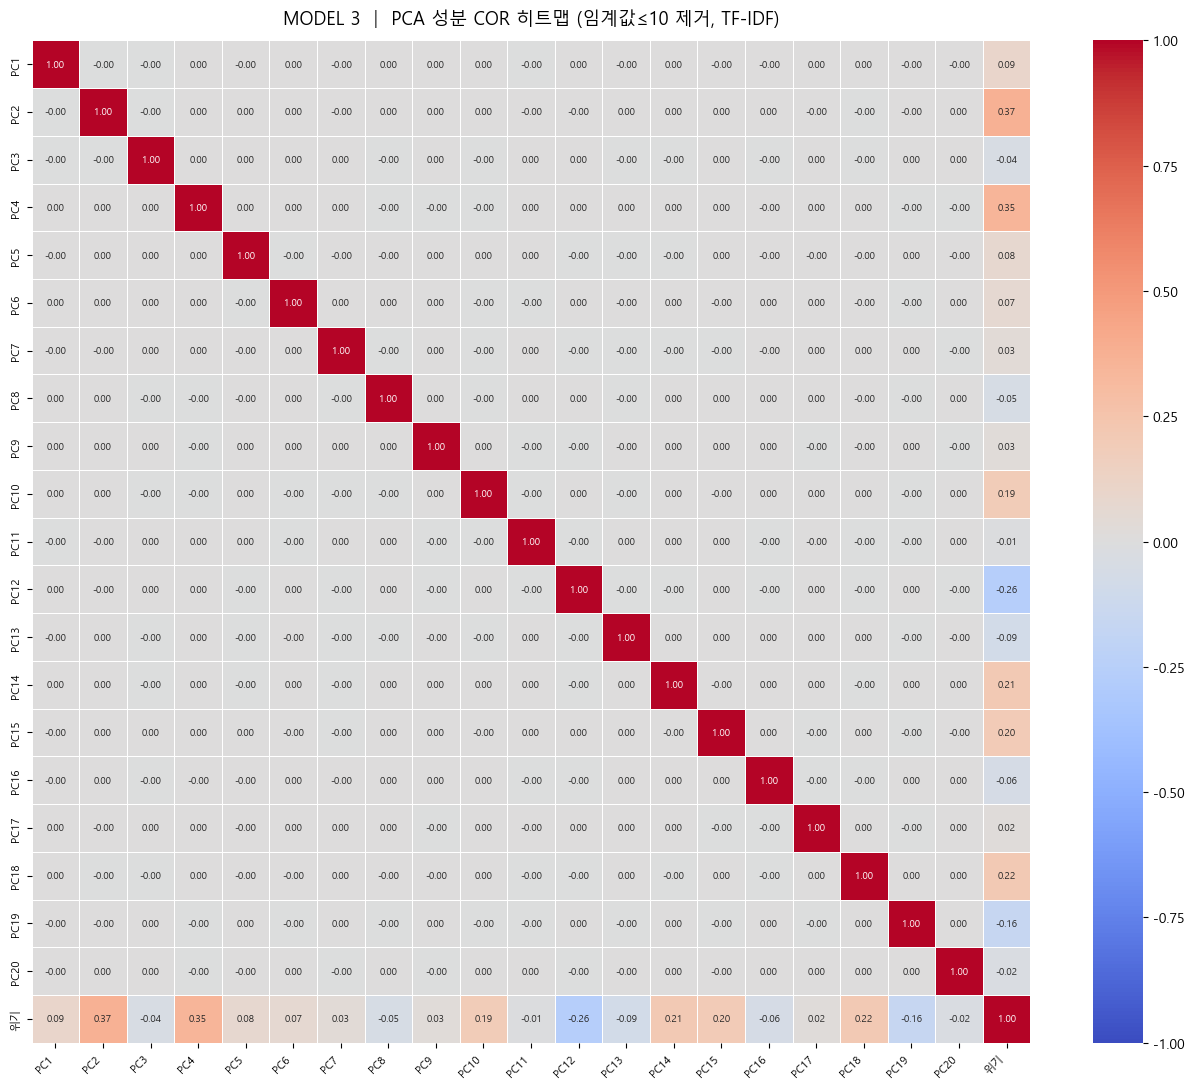

히트맵 저장 → model3_cor_heatmap.png


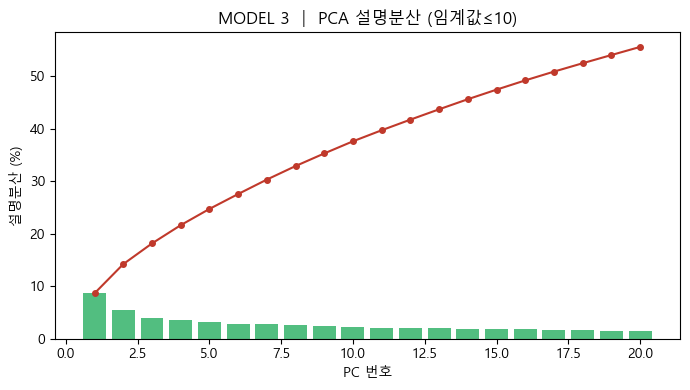


─── MODEL 3 │ Logistic Regression ───────────────────
  LOO-CV Accuracy : 0.6774 ± 0.4675
  PC 계수         : {'PC1': np.float64(0.369), 'PC2': np.float64(1.411), 'PC3': np.float64(-0.15), 'PC4': np.float64(1.222), 'PC5': np.float64(0.254), 'PC6': np.float64(0.217), 'PC7': np.float64(0.112), 'PC8': np.float64(-0.152), 'PC9': np.float64(0.081), 'PC10': np.float64(0.585), 'PC11': np.float64(-0.039), 'PC12': np.float64(-0.772), 'PC13': np.float64(-0.253), 'PC14': np.float64(0.622), 'PC15': np.float64(0.566), 'PC16': np.float64(-0.156), 'PC17': np.float64(0.067), 'PC18': np.float64(0.594), 'PC19': np.float64(-0.438), 'PC20': np.float64(-0.061)}

  위기 상관 상위 PC별 원단어 기여 Top-10:
    PC2: ['賊', '太皇太后', '大將', '官兵', '軍', '大兵', '皇太后', '赴', '陞', '岳州']
    PC4: ['朕', '鰲', '隄', '駐蹕', '拜', '罪', '皇太子', '二百', '引河', '喇嘛']
    PC12: ['鰲', '阿哥', '提調', '皇太子', '禩', '朕', '拜', '罪', '禵', '盛京']

─── MODEL 3 │ Lasso ──────────────────────────────────
  Best Alpha      : 0.006581
  LOO-CV Accuracy : 0.7097
  선택된 PC

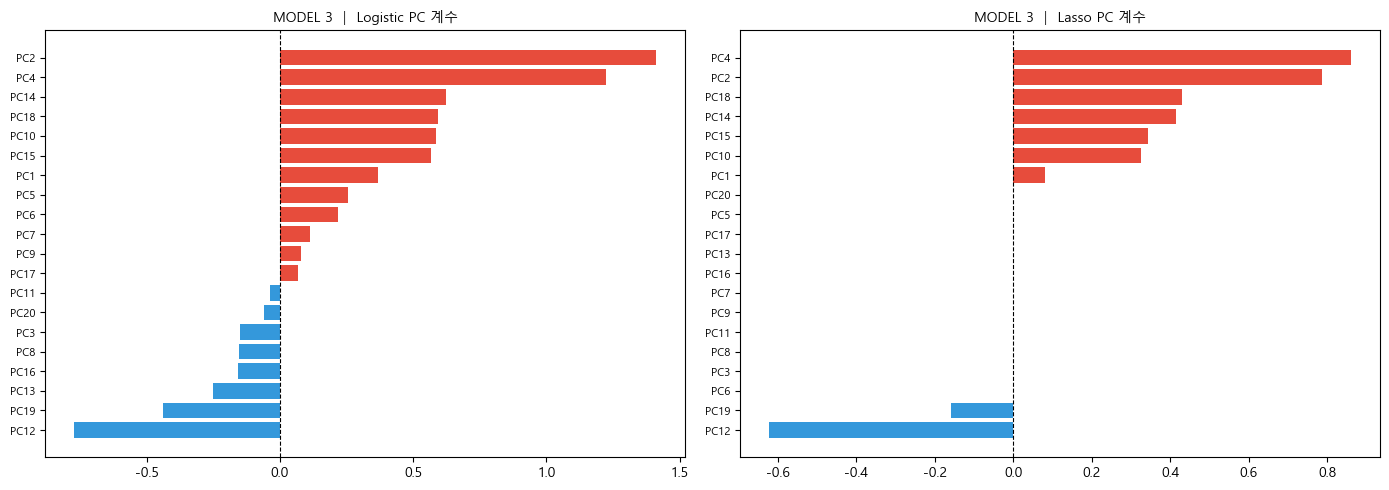

계수 차트 저장 → model3_coef.png


In [38]:
# ============================================================
# MODEL 3 ─ 임계값≤10 재처리 + TF-IDF + PCA
#           COR 히트맵  +  Logistic(LOO-CV)  +  Lasso(LOO-CV)
# ============================================================

LOO    = LeaveOneOut()
N_COMP = 20

# ── (A) 원본 재로드 & 임계값 10 이하 희귀단어 재처리 ────────
ORIG_PATH = "kangxi_master_A_1661_1722.csv"   # ← 경로 수정
PARTICLES = set([
    "之","乎","者","也","而","以","於","其","為","與","乃","則","所","矣",
    "焉","哉","夫","且","若","如","兮","耳","爾","耶","邪","歟",
    "不","無","非","莫","勿","毋","弗",
    "此","彼","是","茲","斯","我","汝",
    "皆","亦","即","各","又","更","已","故","因","遂","從","及",
    "或","仍","再","復","旋","頓","俱","並","并","尚","猶",
    "自","至","由","用","共","同","均","咸","悉",
    "等","諸","餘","凡","每","盡","全","一","二","三","四",
    "五","六","七","八","九","十","百","千","萬","億","兩","半",
    "上","下","前","後","中","內","外","左","右","東","西","南","北",
    "今","昔","先","初","末","始","終","早","晚","久","頃",
    "有","曰","云","言","稱","謂","令","使","命","允","欽","奉","遵",
    "奏","覆","議","准","照","依",
    "大","小","多","少","新","舊","正","副","主","次","高","低",
    "都","公","行","事","日","月","年","時","處","地","人","王",
    "臣","民","兵","官","子","父","母","兄","弟","姪","孫",
    "○","●","◎","△","□","■","▲","▼","◆","◇","☆","★",
    "零","壹","貳","參","肆","伍","陸","柒","捌","玖","拾","佰","仟",
    "위기",
])

df_orig     = pd.read_csv(ORIG_PATH, encoding="utf-8-sig", index_col=0)
df_orig.index = df_orig.index.astype(str)
df_t3       = df_orig.replace("NULL", 0).fillna(0).astype(int).T.copy()
y3_ser      = df_t3["위기"].copy()
y3_bin      = (y3_ser.values >= 1).astype(int)

df_t3 = df_t3.drop(columns=[c for c in df_t3.columns if c in PARTICLES])

# 임계값 ≤10 희귀단어 파생속성 (리키지 방지: 희귀단어 묶기만 하고 특성에서 제외)
col_sums3  = df_t3.sum(axis=0)
rare3_cols = df_t3.columns[(col_sums3 <= 10)].tolist()
# 희귀단어 그냥 제거 (리키지 없이)
df_t3 = df_t3.drop(columns=[c for c in rare3_cols if c in df_t3.columns])
df_t3 = df_t3.drop(columns=["위기"], errors="ignore").fillna(0).astype(int)

X3_raw = df_t3.astype(float)
print(f"임계값≤10 희귀단어 {len(rare3_cols):,}개 제거 후 shape : {X3_raw.shape}")

# ── (B) TF-IDF 변환 ─────────────────────────────────────────
tfidf3      = TfidfTransformer(norm="l2", use_idf=True, smooth_idf=True)
X3_tfidf    = tfidf3.fit_transform(X3_raw.values)
X3_tfidf_df = pd.DataFrame(X3_tfidf.toarray(), columns=X3_raw.columns, index=X3_raw.index)
print(f"TF-IDF 변환 후 shape : {X3_tfidf_df.shape}")

# ── (C) PCA 차원축소 ─────────────────────────────────────────
pca3    = PCA(n_components=N_COMP, random_state=42)
X3_pca  = pca3.fit_transform(X3_tfidf_df)
exp3    = pca3.explained_variance_ratio_.cumsum()
print(f"PCA {N_COMP}개 성분 누적 설명분산 : {exp3[-1]*100:.1f}%")

X3_pca_df = pd.DataFrame(
    X3_pca, columns=[f"PC{i+1}" for i in range(N_COMP)], index=X3_raw.index
)

# ── (D) COR 히트맵 ───────────────────────────────────────────
corr3     = X3_pca_df.copy()
corr3["위기"] = y3_bin.astype(float)
corr_mat3 = corr3.corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_mat3, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.4, ax=ax, annot_kws={"size": 7})
ax.set_title("MODEL 3 │ PCA 성분 COR 히트맵 (임계값≤10 제거, TF-IDF)", fontsize=13, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("model3_cor_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("히트맵 저장 → model3_cor_heatmap.png")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, N_COMP+1), pca3.explained_variance_ratio_*100, color="#27ae60", alpha=0.8)
ax.plot(range(1, N_COMP+1), exp3*100, "o-", color="#c0392b", lw=1.5, ms=4)
ax.set_xlabel("PC 번호"); ax.set_ylabel("설명분산 (%)")
ax.set_title("MODEL 3 │ PCA 설명분산 (임계값≤10)")
plt.tight_layout()
plt.savefig("model3_pca_var.png", dpi=150, bbox_inches="tight")
plt.show()

# ── (E) Logistic Regression (LOO-CV) ────────────────────────
lr3 = LogisticRegression(
    penalty="l2", C=1.0, max_iter=3000,
    class_weight="balanced", random_state=42
)
lr3_loo  = cross_val_score(lr3, X3_pca_df, y3_bin, cv=LOO, scoring="accuracy")
lr3.fit(X3_pca_df, y3_bin)
lr3_coef = pd.Series(lr3.coef_[0], index=X3_pca_df.columns)

loadings3  = pd.DataFrame(pca3.components_,
                           index=X3_pca_df.columns, columns=X3_raw.columns)
top_pc3    = corr_mat3.drop(index="위기")["위기"].abs().nlargest(3).index.tolist()

print(f"\n─── MODEL 3 │ Logistic Regression ───────────────────")
print(f"  LOO-CV Accuracy : {lr3_loo.mean():.4f} ± {lr3_loo.std():.4f}")
print(f"  PC 계수         : {dict(zip(lr3_coef.index, lr3_coef.round(3).values))}")
print(f"\n  위기 상관 상위 PC별 원단어 기여 Top-10:")
for pc in top_pc3:
    top_words = loadings3.loc[pc].abs().nlargest(10).index.tolist()
    print(f"    {pc}: {top_words}")

# ── (F) Lasso (LOO-CV) ───────────────────────────────────────
lasso3_cv  = LassoCV(cv=5, max_iter=5000, random_state=42).fit(X3_pca_df, y3_bin.astype(float))
lasso3     = Lasso(alpha=lasso3_cv.alpha_, max_iter=5000).fit(X3_pca_df, y3_bin.astype(float))
lasso3_coef = pd.Series(lasso3.coef_, index=X3_pca_df.columns)

def lasso_loo_acc(X, y, alpha):
    preds = []
    for train, test in LeaveOneOut().split(X):
        m = Lasso(alpha=alpha, max_iter=5000)
        m.fit(X[train], y[train])
        preds.append((m.predict(X[test])[0] >= 0.5).astype(int))
    return accuracy_score(y, preds)

lasso3_loo_val = lasso_loo_acc(X3_pca_df.values, y3_bin.astype(float), lasso3_cv.alpha_)
sel3 = lasso3_coef[lasso3_coef != 0].index.tolist()

print(f"\n─── MODEL 3 │ Lasso ──────────────────────────────────")
print(f"  Best Alpha      : {lasso3_cv.alpha_:.6f}")
print(f"  LOO-CV Accuracy : {lasso3_loo_val:.4f}")
print(f"  선택된 PC       : {len(sel3)}개  {sel3}")
if sel3:
    print(f"\n  Lasso 선택 PC별 원단어 기여 Top-10:")
    for pc in sel3:
        top_words = loadings3.loc[pc].abs().nlargest(10).index.tolist()
        print(f"    {pc}: {top_words}")

# ── (G) 세 모델 LOO-CV 정확도 비교표 ────────────────────────
print("\n" + "="*58)
print("📊 세 모델 LOO-CV 정확도 비교 (chance = {:.4f})".format(
    max(y3_bin.mean(), 1-y3_bin.mean())))
print("="*58)
rows = []
try:
    rows.append({"모델":"MODEL1 Logistic", "LOO-CV Acc":f"{lr1_loo_mean:.4f}"})
    rows.append({"모델":"MODEL1 Lasso",    "LOO-CV Acc":f"{lasso1_loo_val:.4f}"})
except: rows.append({"모델":"MODEL1","LOO-CV Acc":"(셀 재실행 필요)"})
try:
    rows.append({"모델":"MODEL2 Logistic", "LOO-CV Acc":f"{lr2_loo_mean:.4f}"})
    rows.append({"모델":"MODEL2 Lasso",    "LOO-CV Acc":f"{lasso2_loo_val:.4f}"})
except: rows.append({"모델":"MODEL2","LOO-CV Acc":"(셀 재실행 필요)"})
rows.append({"모델":"MODEL3 Logistic", "LOO-CV Acc":f"{lr3_loo.mean():.4f}"})
rows.append({"모델":"MODEL3 Lasso",    "LOO-CV Acc":f"{lasso3_loo_val:.4f}"})
print(pd.DataFrame(rows).to_string(index=False))

# ── (H) 계수 차트 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, coef) in zip(axes, [
        ("Logistic PC 계수", lr3_coef.sort_values()),
        ("Lasso PC 계수",    lasso3_coef.sort_values())
    ]):
    colors = ["#e74c3c" if v > 0 else "#3498db" for v in coef.values]
    ax.barh(coef.index, coef.values, color=colors)
    ax.axvline(0, color="black", lw=0.8, linestyle="--")
    ax.set_title(f"MODEL 3 │ {title}", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("model3_coef.png", dpi=150, bbox_inches="tight")
plt.show()
print("계수 차트 저장 → model3_coef.png")


✅ 앞 셀 변수 감지 — 재사용합니다.
LOO-CV 계산 중… (약 10~20초 소요)
  M1  Acc=91.9%  AUC=0.989  F1=0.906
  M2  Acc=67.7%  AUC=0.729  F1=0.655
  M3  Acc=67.7%  AUC=0.742  F1=0.655


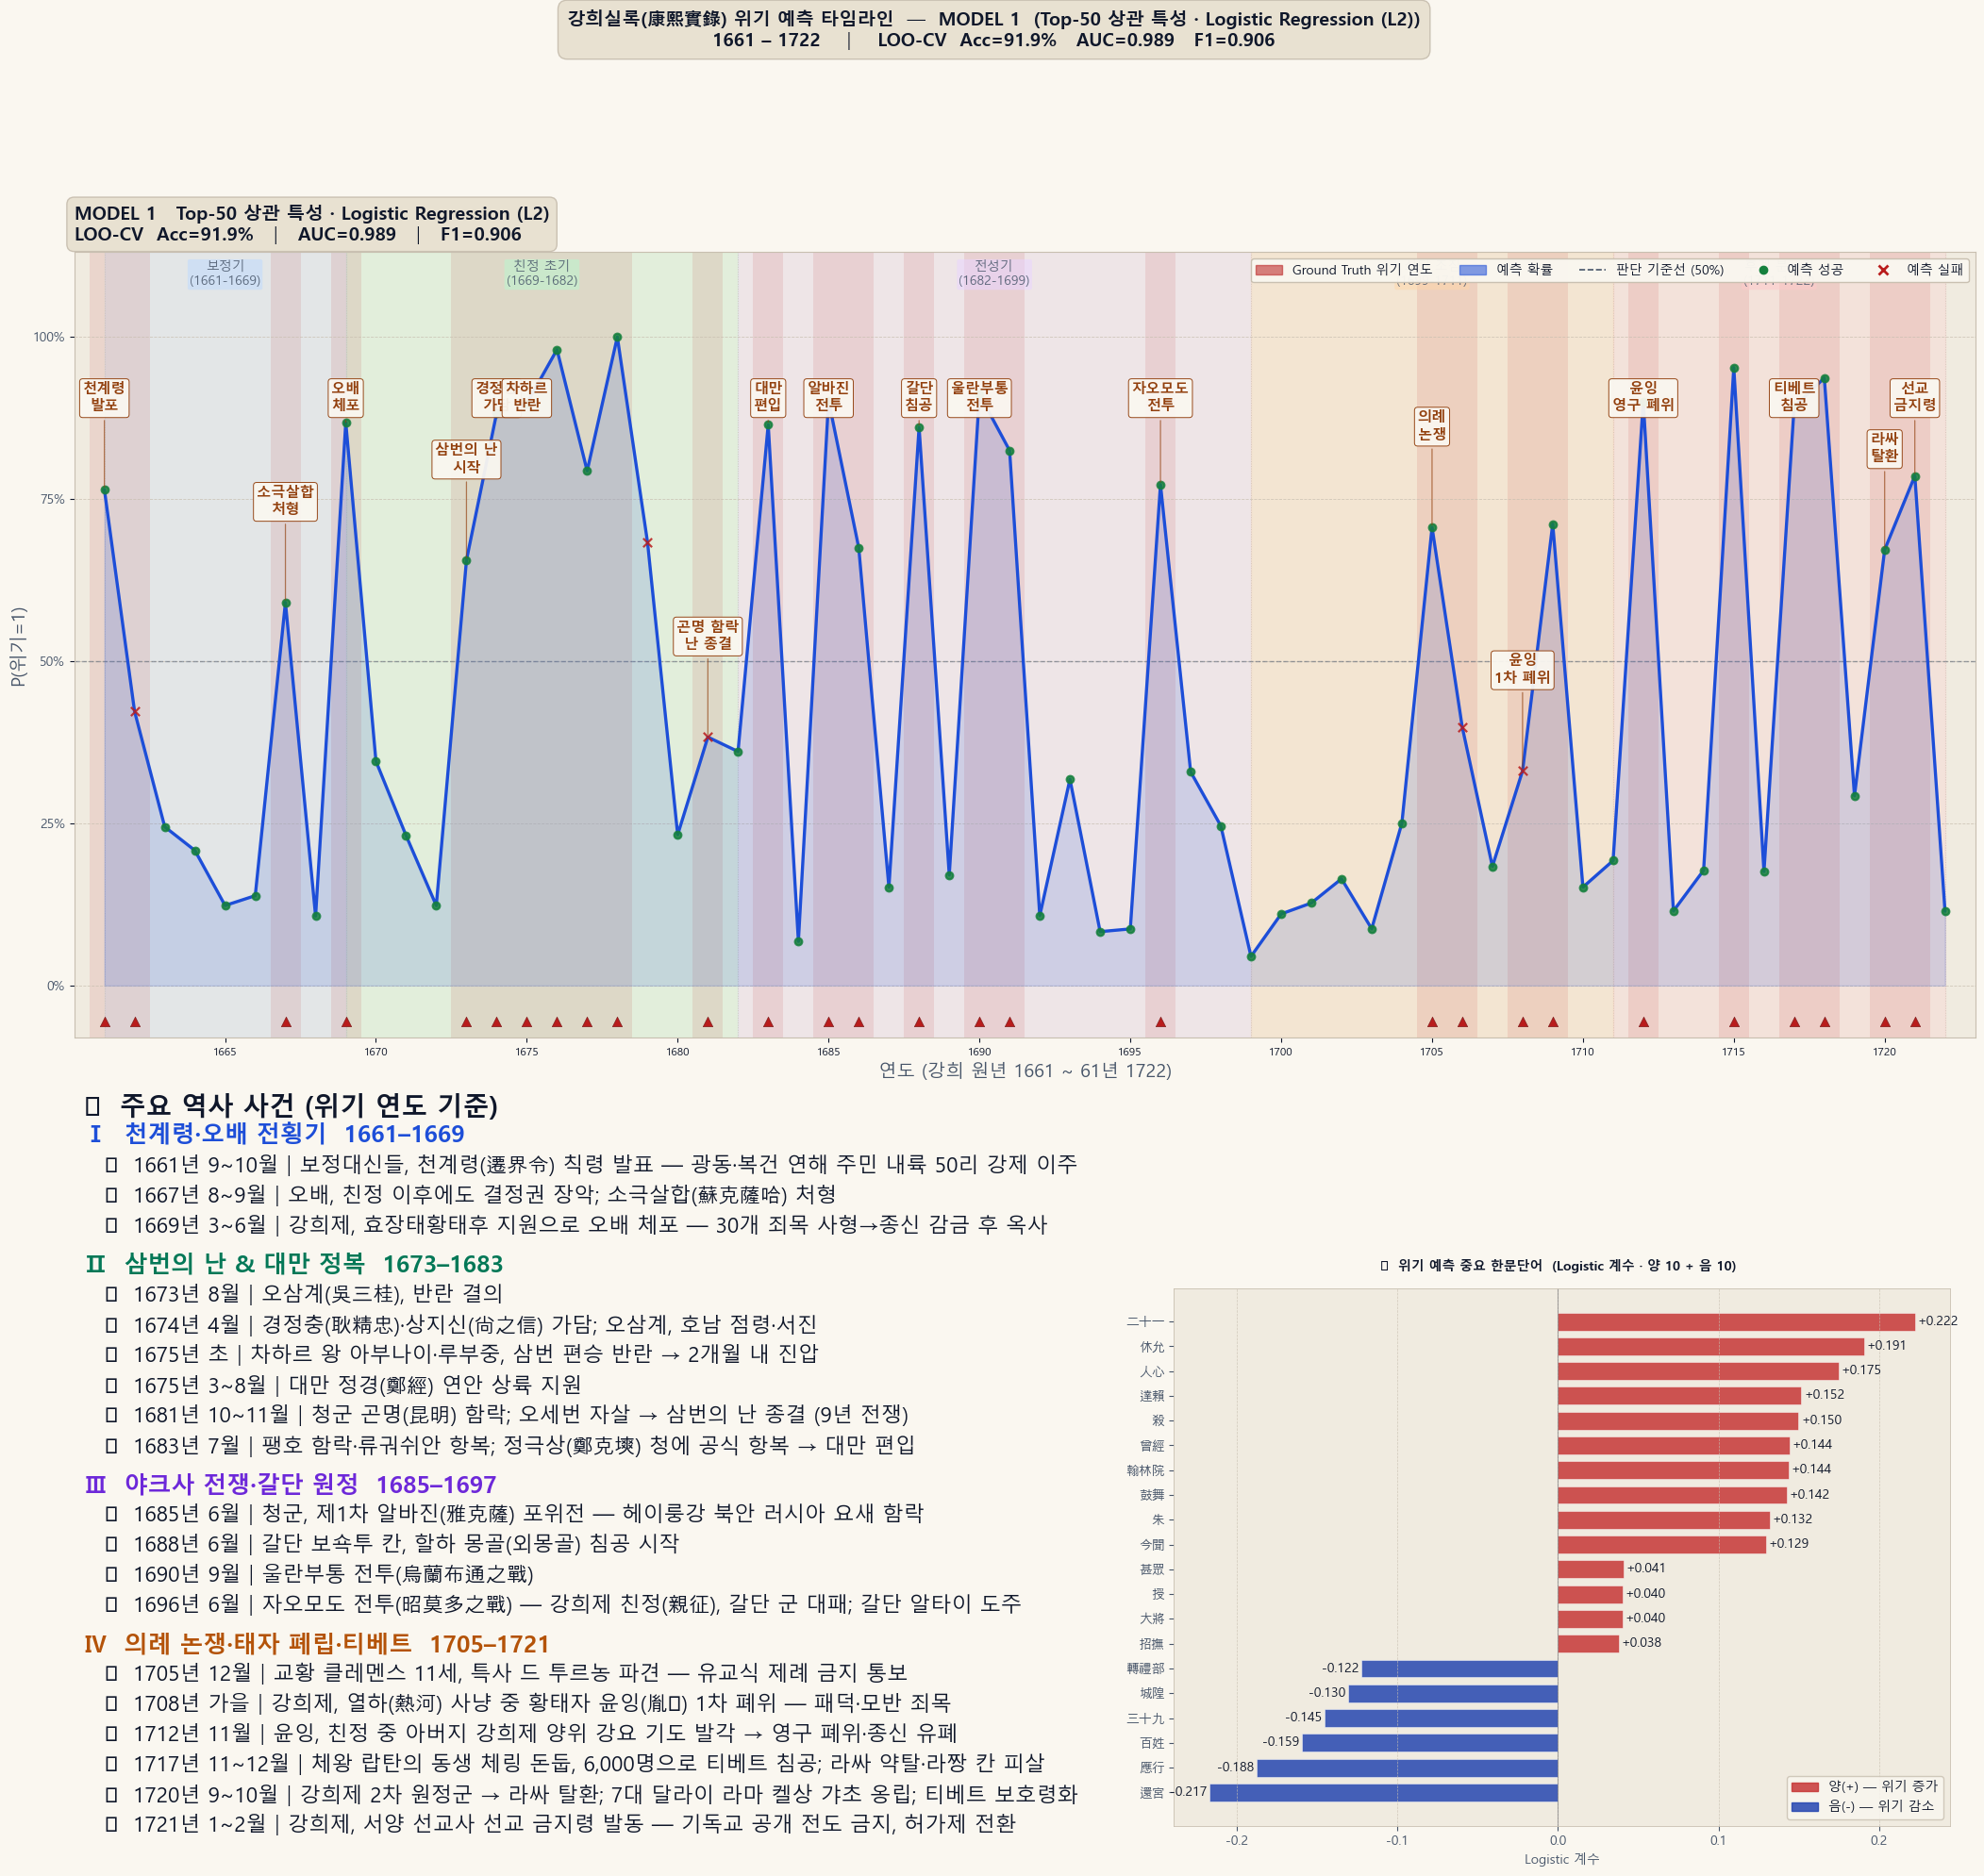

✅ 저장 → kangxi_light_model1.png


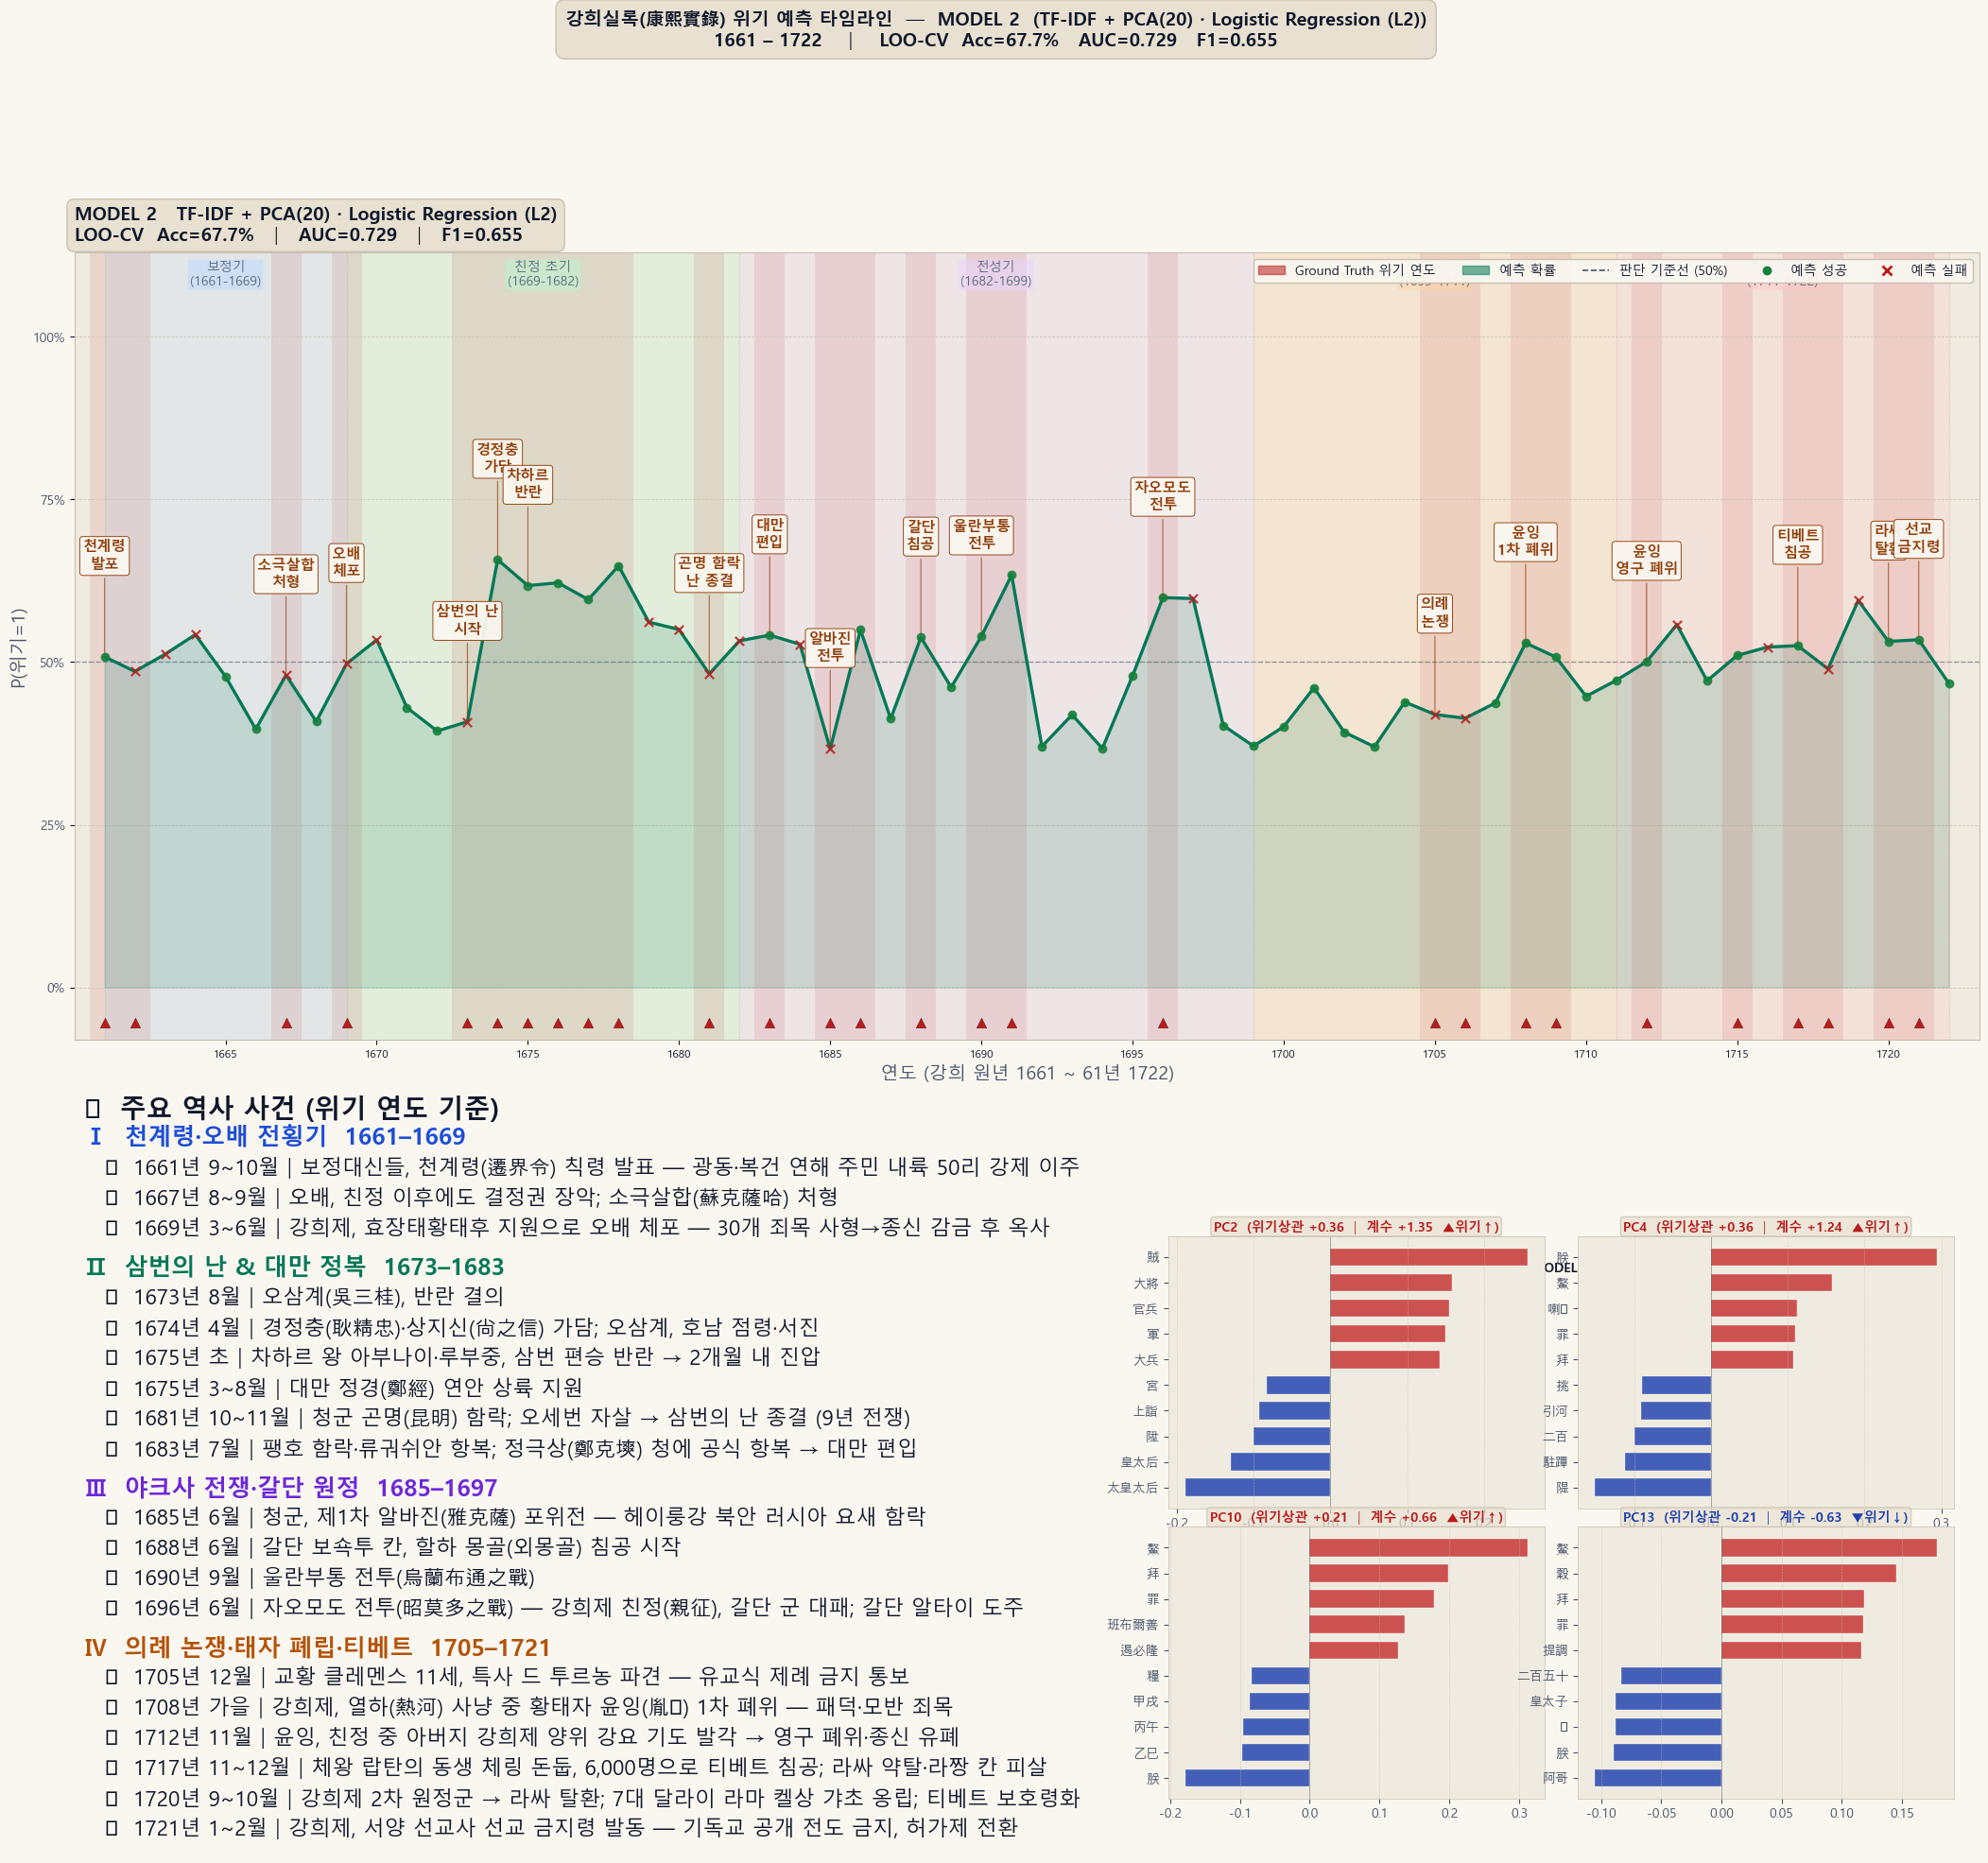

✅ 저장 → kangxi_light_model2.png


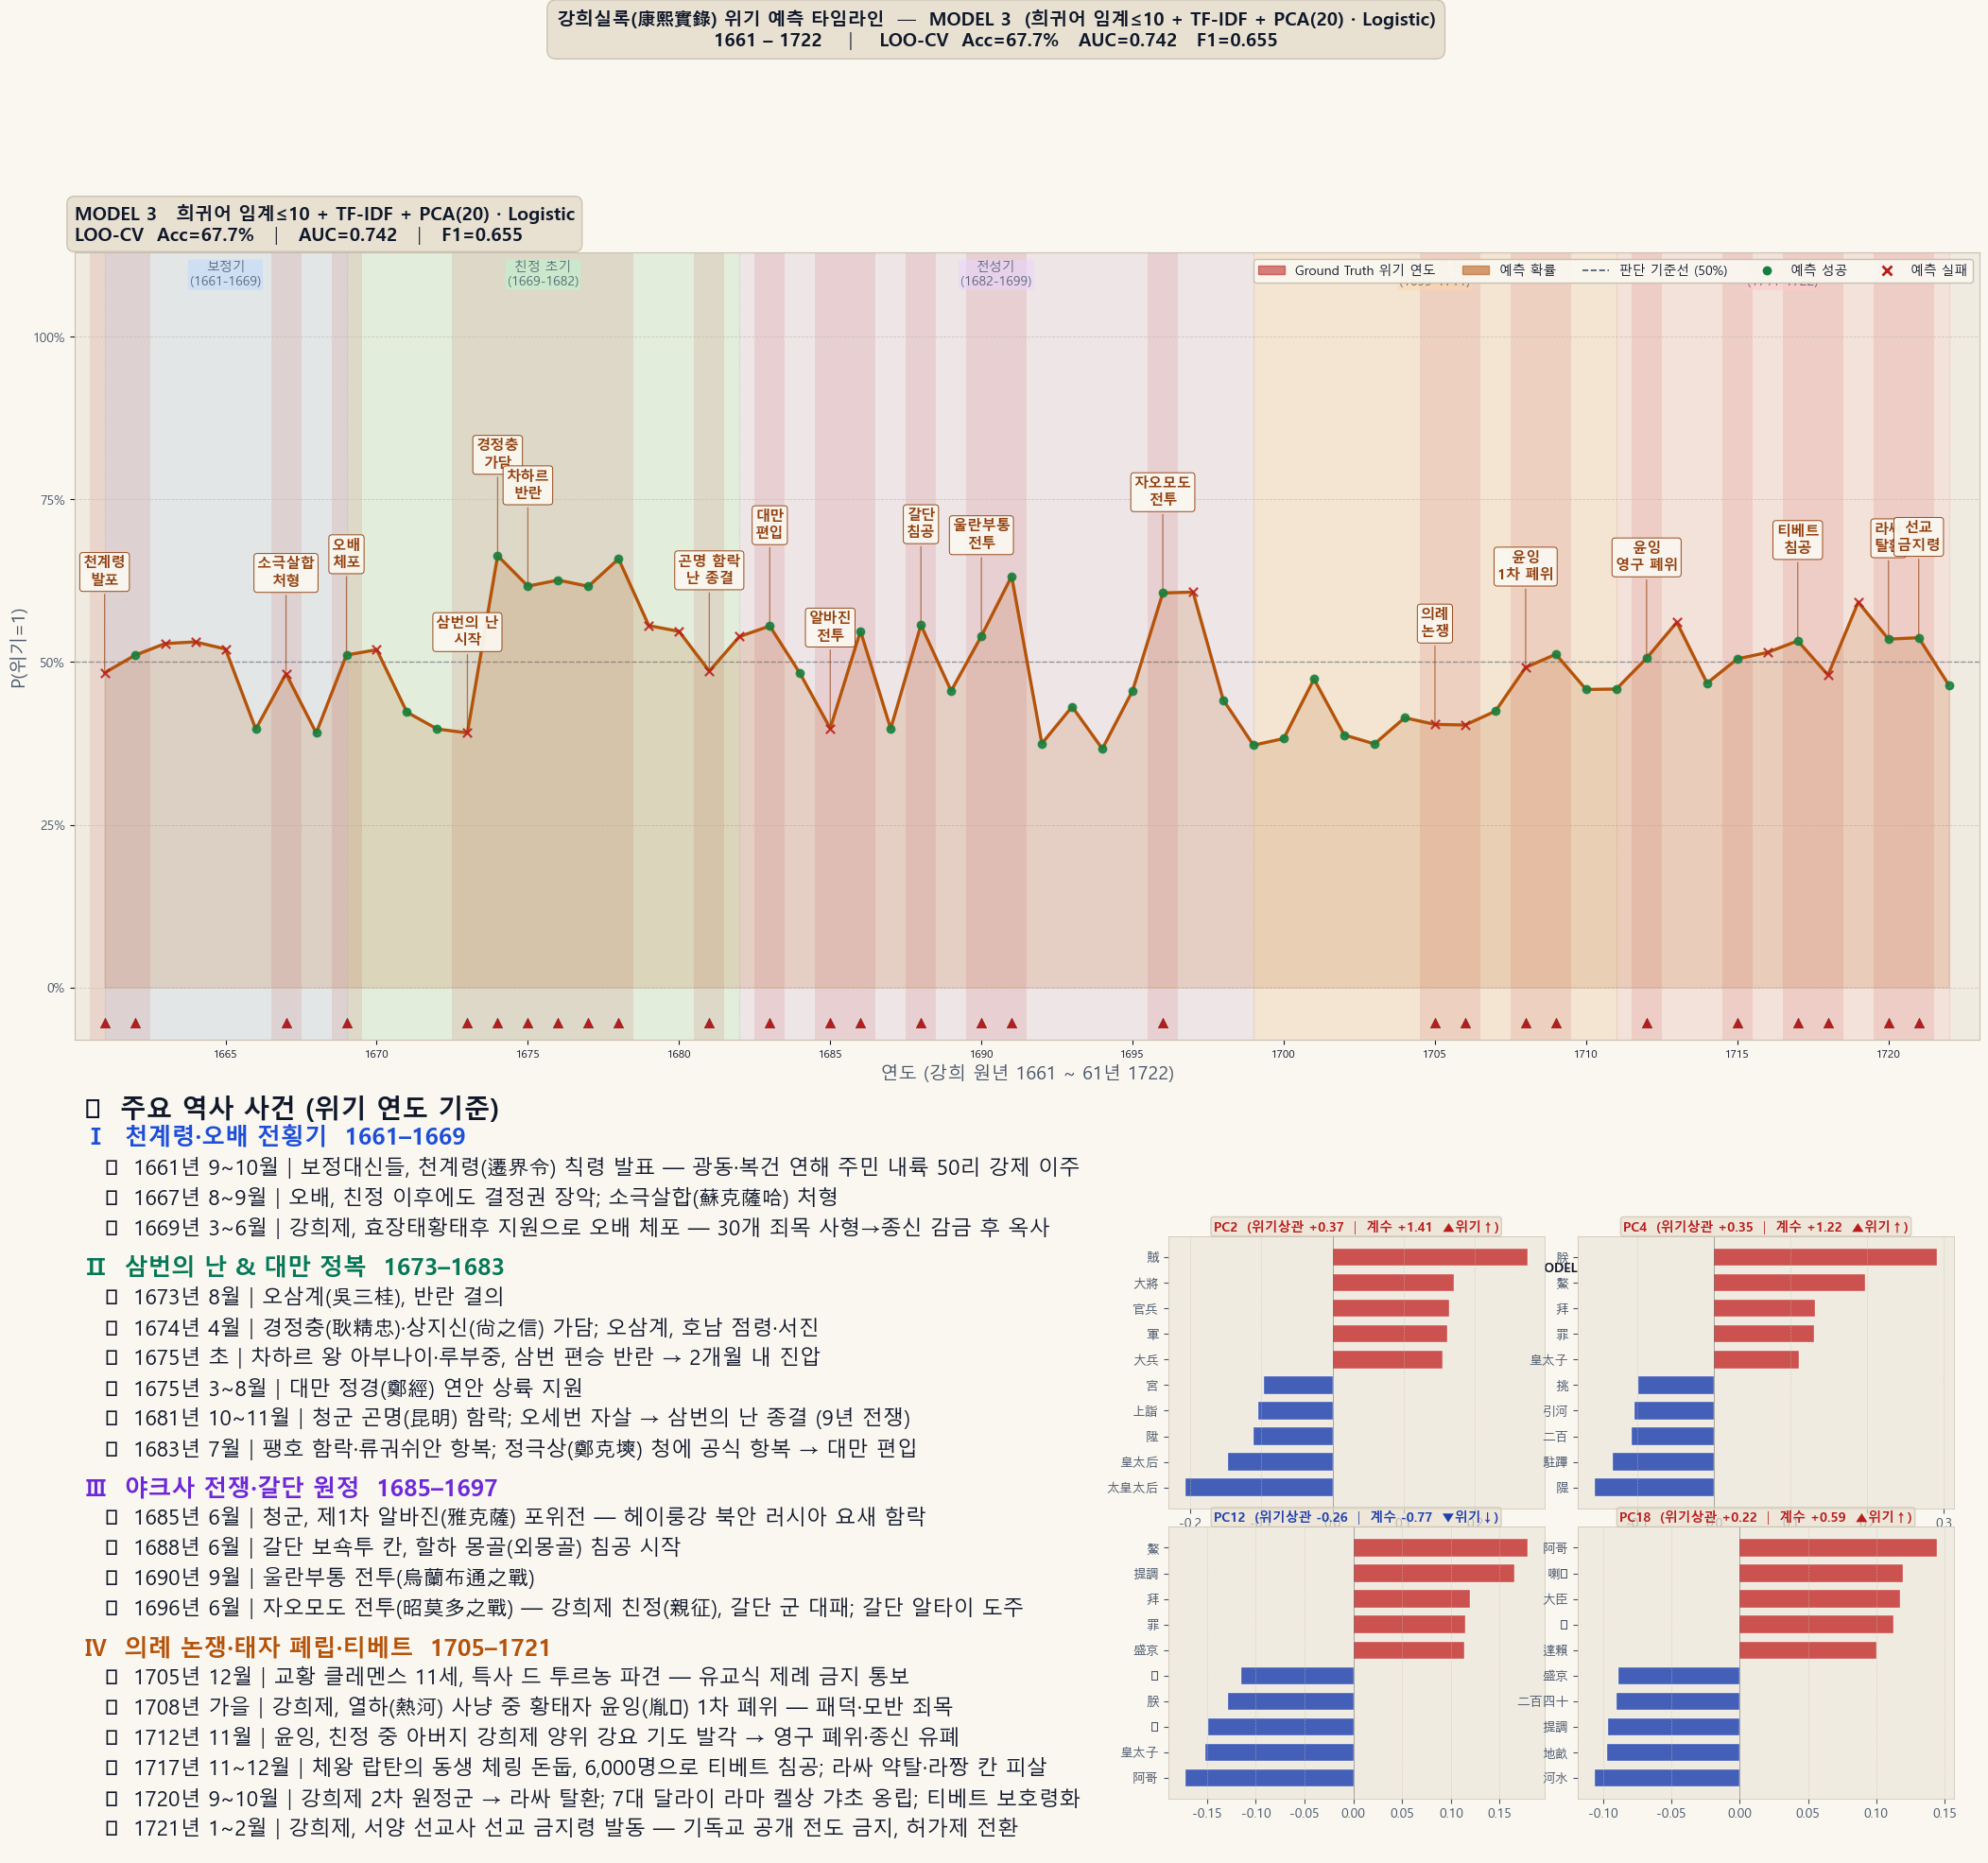

✅ 저장 → kangxi_light_model3.png


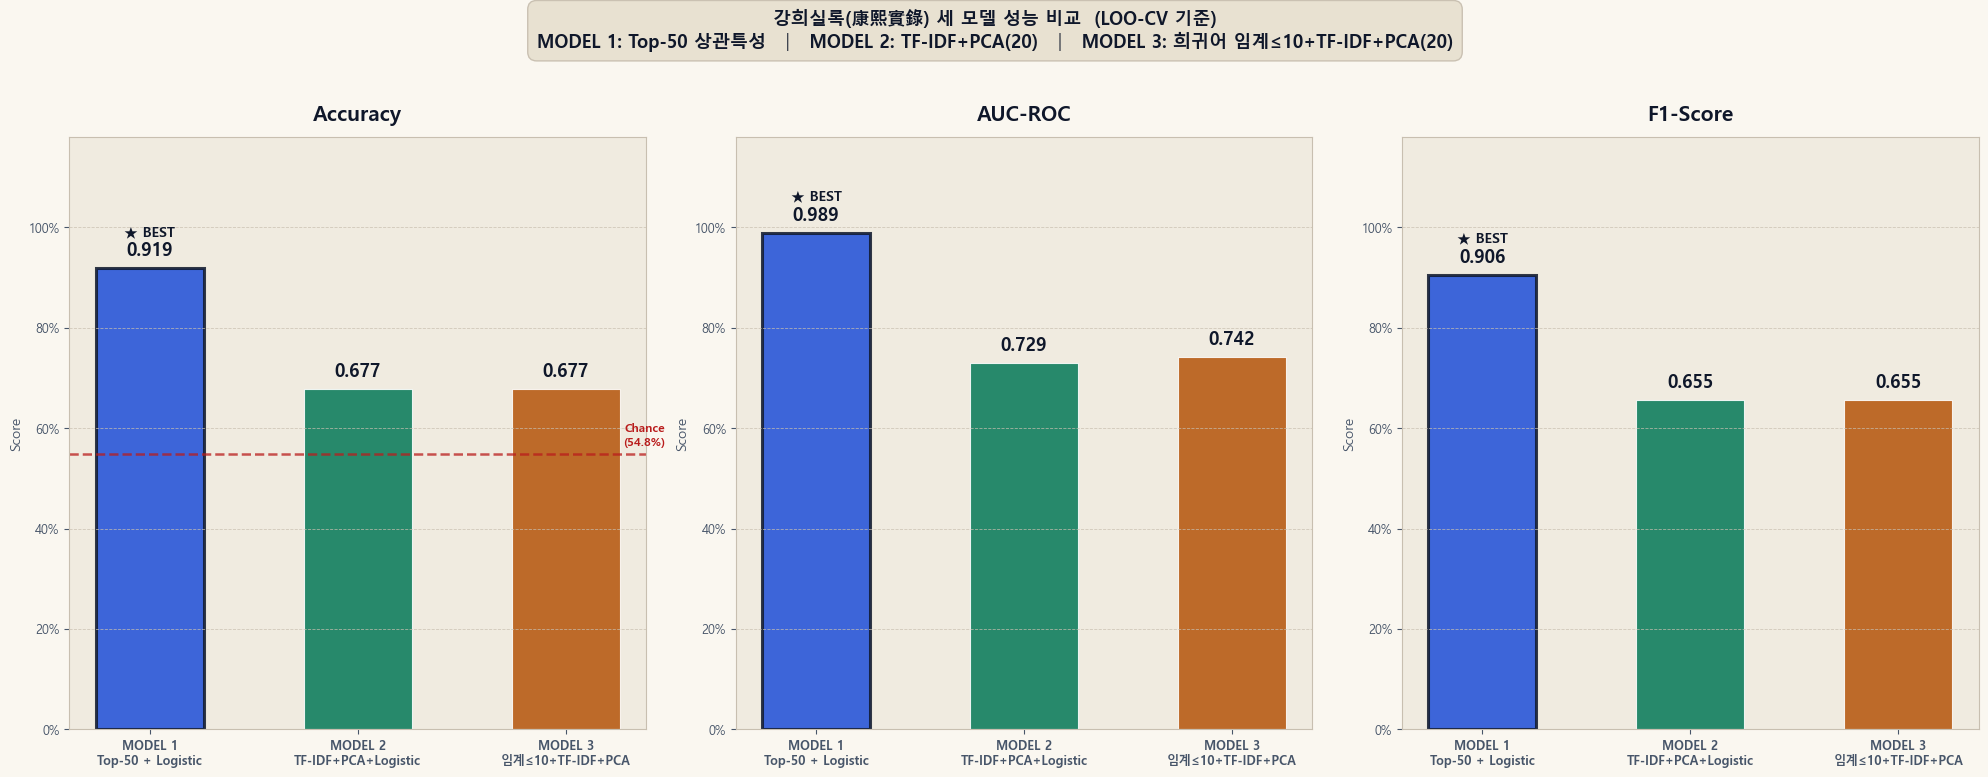

✅ 저장 → kangxi_light_comparison.png

🎉 총 4개 이미지 생성 완료!
예측 타임라인 시각화 완료
예측 타임라인 이미지 저장 → kangxi_prediction_timeline.png


<Figure size 640x480 with 0 Axes>

In [39]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  PREDICTION TIMELINE — 라이트 테마  (#FAF7F0 배경 / #0F172A 글씨)       ║
# ║  ① 모델별 개별 이미지 3장 (타임라인 + 이벤트 주석 + 중요 한문단어)      ║
# ║  ② 세 모델 성능 비교 이미지 1장                                          ║
# ║  ※ MODEL 1·2·3 셀 실행 후 이 셀을 실행하세요                            ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import warnings; warnings.filterwarnings("ignore")
import copy, platform, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_auc_score, f1_score

# ── 한글 폰트 ──────────────────────────────────────────────────────────────
if platform.system() == "Linux":
    os.system("apt-get install -y fonts-nanum > /dev/null 2>&1")
    fm._load_fontmanager(try_read_cache=False)
    _n = [f for f in fm.findSystemFonts() if "Nanum" in f]
    plt.rcParams["font.family"] = fm.FontProperties(fname=_n[0]).get_name() if _n else "DejaVu Sans"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ════════════════════════════════════════════════════════════════════════════
# 0. 데이터/모델 로드 — 앞 셀 변수가 없을 때 자동 재생성
# ════════════════════════════════════════════════════════════════════════════
try:
    _ = df_raw
    print("✅ 앞 셀 변수 감지 — 재사용합니다.")
except NameError:
    print("⚠️  앞 셀 변수 없음 — CSV에서 자동 재생성합니다…")
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.feature_extraction.text import TfidfTransformer

    DATA_PATH = "kangxi_master_A_preprocessed.csv"   # ← 경로 조정
    ORIG_PATH = "kangxi_master_A_1661_1722.csv"      # ← 경로 조정

    df_raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig", index_col=0)
    df_raw.index = df_raw.index.astype(str)
    y_raw  = df_raw["위기"].values.astype(int)
    y_bin  = (y_raw >= 1).astype(int)
    X_full = df_raw.drop(columns=["위기","희귀 단어 (양)","희귀 단어 (음)"], errors="ignore").astype(float)

    # ── MODEL 1
    scaler1 = StandardScaler()
    X1_all  = pd.DataFrame(scaler1.fit_transform(X_full), columns=X_full.columns, index=X_full.index)
    corr_y  = X1_all.corrwith(pd.Series(y_bin.astype(float), index=X1_all.index))
    X1      = X1_all[corr_y.abs().nlargest(50).index]
    lr1     = LogisticRegression(penalty="l2", C=0.05, max_iter=3000,
                                  class_weight="balanced", solver="lbfgs", random_state=42)
    lr1.fit(X1, y_bin)
    lr1_coef = pd.Series(lr1.coef_[0], index=X1.columns)

    # ── MODEL 2
    tfidf2    = TfidfTransformer(norm="l2", use_idf=True, smooth_idf=True)
    X2_t      = tfidf2.fit_transform(X_full.values).toarray()
    pca2      = PCA(n_components=20, random_state=42)
    X2_pca_df = pd.DataFrame(pca2.fit_transform(X2_t),
                               columns=[f"PC{i+1}" for i in range(20)], index=X_full.index)
    lr2       = LogisticRegression(penalty="l2", C=1.0, max_iter=3000,
                                    class_weight="balanced", random_state=42)
    lr2.fit(X2_pca_df, y_bin)
    lr2_coef  = pd.Series(lr2.coef_[0], index=X2_pca_df.columns)
    loadings2 = pd.DataFrame(pca2.components_, index=X2_pca_df.columns, columns=X_full.columns)
    _tmp2 = X2_pca_df.copy(); _tmp2["위기"] = y_bin.astype(float)
    corr_mat2 = _tmp2.corr()

    # ── MODEL 3 (희귀어 임계 ≤10)
    PARTICLES = set(["之","乎","者","也","而","以","於","其","為","與","乃","則","所","矣",
                      "焉","哉","夫","且","若","如","兮","耳","爾","耶","邪","歟",
                      "不","無","非","莫","勿","毋","弗","此","彼","是","茲","斯","我","汝",
                      "皆","亦","即","各","又","更","已","故","因","遂","從","及",
                      "或","仍","再","復","旋","頓","俱","並","并","尚","猶",
                      "自","至","由","用","共","同","均","咸","悉",
                      "等","諸","餘","凡","每","盡","全","一","二","三","四",
                      "五","六","七","八","九","十","百","千","萬","億","兩","半",
                      "上","下","前","後","中","內","外","左","右","東","西","南","北",
                      "今","昔","先","初","末","始","終","早","晚","久","頃",
                      "有","曰","云","言","稱","謂","令","使","命","允","欽","奉","遵",
                      "奏","覆","議","准","照","依",
                      "大","小","多","少","新","舊","正","副","主","次","高","低",
                      "都","公","行","事","日","月","年","時","處","地","人","王",
                      "臣","民","兵","官","子","父","母","兄","弟","姪","孫","위기"])
    df_orig = pd.read_csv(ORIG_PATH, encoding="utf-8-sig", index_col=0)
    df_orig.index = df_orig.index.astype(str)
    df_t3   = df_orig.replace("NULL",0).fillna(0).astype(int).T.copy()
    y3_bin  = (df_t3["위기"].values >= 1).astype(int)
    df_t3   = df_t3.drop(columns=[c for c in df_t3.columns if c in PARTICLES])
    rare3   = df_t3.columns[df_t3.sum(axis=0) <= 10].tolist()
    df_t3   = df_t3.drop(columns=[c for c in rare3 if c in df_t3.columns])
    X3_raw  = df_t3.drop(columns=["위기"], errors="ignore").fillna(0).astype(float)
    tfidf3  = TfidfTransformer(norm="l2", use_idf=True, smooth_idf=True)
    X3_t    = tfidf3.fit_transform(X3_raw.values).toarray()
    pca3    = PCA(n_components=20, random_state=42)
    X3_pca_df = pd.DataFrame(pca3.fit_transform(X3_t),
                               columns=[f"PC{i+1}" for i in range(20)], index=X3_raw.index)
    lr3       = LogisticRegression(penalty="l2", C=1.0, max_iter=3000,
                                    class_weight="balanced", random_state=42)
    lr3.fit(X3_pca_df, y3_bin)
    lr3_coef  = pd.Series(lr3.coef_[0], index=X3_pca_df.columns)
    loadings3 = pd.DataFrame(pca3.components_, index=X3_pca_df.columns, columns=X3_raw.columns)
    _tmp3 = X3_pca_df.copy(); _tmp3["위기"] = y3_bin.astype(float)
    corr_mat3 = _tmp3.corr()

# ════════════════════════════════════════════════════════════════════════════
# 1. 라이트 테마 팔레트
# ════════════════════════════════════════════════════════════════════════════
BG    = "#FAF7F0"   # 크림 배경
PANEL = "#F0EBE0"   # 패널 배경
P2    = "#E8E0D0"   # 보조 패널 (타이틀 박스)
GRID  = "#C8BFB0"   # 그리드 선
TM    = "#0F172A"   # 텍스트 메인 (다크 네이비)
TS    = "#475569"   # 텍스트 서브 (슬레이트)
ANNO  = "#92400E"   # 주석 글자 (앰버-브라운)
GT    = "#B91C1C"   # Ground Truth (짙은 빨강)
TLINE = "#475569"   # 기준선 (50%)
W_POS = "#C53030"   # 양수 단어 바 (레드)
W_NEG = "#1E40AF"   # 음수 단어 바 (블루)
OK_C  = "#15803D"   # 예측 성공 마커 (그린)
ERR_C = "#B91C1C"   # 예측 실패 마커 (레드)

# 시대 구분 — 파스텔
ERAS = [
    (1661, 1669, "#BFDBFE", "보정기\n(1661-1669)"),
    (1669, 1682, "#BBF7D0", "친정 초기\n(1669-1682)"),
    (1682, 1699, "#E9D5FF", "전성기\n(1682-1699)"),
    (1699, 1711, "#FED7AA", "쇠퇴 조짐\n(1699-1711)"),
    (1711, 1722, "#FECACA", "후계 분쟁기\n(1711-1722)"),
]

M_COLORS = ["#1D4ED8", "#047857", "#B45309"]  # 모델별 색 (블루/그린/앰버)

# ════════════════════════════════════════════════════════════════════════════
# 2. 이벤트 데이터
# ════════════════════════════════════════════════════════════════════════════
years = np.array(df_raw.index.astype(int))

EVENTS_SHORT = {
    1661: "천계령\n발포",    1667: "소극살합\n처형",  1669: "오배\n체포",
    1673: "삼번의 난\n시작", 1674: "경정충\n가담",    1675: "차하르\n반란",
    1681: "곤명 함락\n난 종결", 1683: "대만\n편입",   1685: "알바진\n전투",
    1688: "갈단\n침공",      1690: "울란부통\n전투",  1696: "자오모도\n전투",
    1705: "의례\n논쟁",      1708: "윤잉\n1차 폐위", 1712: "윤잉\n영구 폐위",
    1717: "티베트\n침공",    1720: "라싸\n탈환",      1721: "선교\n금지령",
}

EVENTS_DETAIL = [
    (1661,True,"1661년 9~10월│보정대신들, 천계령(遷界令) 칙령 발표 — 광동·복건 연해 주민 내륙 50리 강제 이주"),
    (1667,True,"1667년 8~9월│오배, 친정 이후에도 결정권 장악; 소극살합(蘇克薩哈) 처형"),
    (1669,True,"1669년 3~6월│강희제, 효장태황태후 지원으로 오배 체포 — 30개 죄목 사형→종신 감금 후 옥사"),
    (1673,True,"1673년 8월│오삼계(吳三桂), 반란 결의"),
    (1674,True,"1674년 4월│경정충(耿精忠)·상지신(尙之信) 가담; 오삼계, 호남 점령·서진"),
    (1675,True,"1675년 초│차하르 왕 아부나이·루부중, 삼번 편승 반란 → 2개월 내 진압"),
    (1675,True,"1675년 3~8월│대만 정경(鄭經) 연안 상륙 지원"),
    (1681,True,"1681년 10~11월│청군 곤명(昆明) 함락; 오세번 자살 → 삼번의 난 종결 (9년 전쟁)"),
    (1683,True,"1683년 7월│팽호 함락·류궈쉬안 항복; 정극상(鄭克塽) 청에 공식 항복 → 대만 편입"),
    (1685,True,"1685년 6월│청군, 제1차 알바진(雅克薩) 포위전 — 헤이룽강 북안 러시아 요새 함락"),
    (1688,True,"1688년 6월│갈단 보쇽투 칸, 할하 몽골(외몽골) 침공 시작"),
    (1690,True,"1690년 9월│울란부통 전투(烏蘭布通之戰)"),
    (1696,True,"1696년 6월│자오모도 전투(昭莫多之戰) — 강희제 친정(親征), 갈단 군 대패; 갈단 알타이 도주"),
    (1705,True,"1705년 12월│교황 클레멘스 11세, 특사 드 투르농 파견 — 유교식 제례 금지 통보"),
    (1708,True,"1708년 가을│강희제, 열하(熱河) 사냥 중 황태자 윤잉(胤礽) 1차 폐위 — 패덕·모반 죄목"),
    (1712,True,"1712년 11월│윤잉, 친정 중 아버지 강희제 양위 강요 기도 발각 → 영구 폐위·종신 유폐"),
    (1717,True,"1717년 11~12월│체왕 랍탄의 동생 체링 돈둡, 6,000명으로 티베트 침공; 라싸 약탈·라짱 칸 피살"),
    (1720,True,"1720년 9~10월│강희제 2차 원정군 → 라싸 탈환; 7대 달라이 라마 켈상 갸초 옹립; 티베트 보호령화"),
    (1721,True,"1721년 1~2월│강희제, 서양 선교사 선교 금지령 발동 — 기독교 공개 전도 금지, 허가제 전환"),
]

# ════════════════════════════════════════════════════════════════════════════
# 3. LOO-CV 예측 확률 계산
# ════════════════════════════════════════════════════════════════════════════
def _loo_proba(model, X, y):
    n = len(y); p = np.zeros(n)
    for tr, te in LeaveOneOut().split(X):
        m = copy.deepcopy(model)
        m.fit(X[tr], y[tr])
        p[te] = m.predict_proba(X[te])[:, 1]
    return p

def _metrics(p, y):
    pred = (p >= .5).astype(int)
    return np.mean(pred == y), roc_auc_score(y, p), f1_score(y, pred, zero_division=0)

print("LOO-CV 계산 중… (약 10~20초 소요)")
proba_m1 = _loo_proba(lr1, X1.values,         y_bin)
proba_m2 = _loo_proba(lr2, X2_pca_df.values,  y_bin)
proba_m3 = _loo_proba(lr3, X3_pca_df.values,  y3_bin)
acc1, auc1, f1_1 = _metrics(proba_m1, y_bin)
acc2, auc2, f1_2 = _metrics(proba_m2, y_bin)
acc3, auc3, f1_3 = _metrics(proba_m3, y3_bin)
print(f"  M1  Acc={acc1:.1%}  AUC={auc1:.3f}  F1={f1_1:.3f}")
print(f"  M2  Acc={acc2:.1%}  AUC={auc2:.3f}  F1={f1_2:.3f}")
print(f"  M3  Acc={acc3:.1%}  AUC={auc3:.3f}  F1={f1_3:.3f}")

# ════════════════════════════════════════════════════════════════════════════
# 4. 중요 단어 추출
# ════════════════════════════════════════════════════════════════════════════
m1_pos = lr1_coef.nlargest(10)
m1_neg = lr1_coef.nsmallest(10)

def get_pca_words(loadings, lr_coef, corr_mat, n_pc=4, n_word=5):
    pc_corr = corr_mat.drop(index="위기")["위기"].abs()
    result  = {}
    for pc in pc_corr.nlargest(n_pc).index:
        ld = loadings.loc[pc]
        result[pc] = dict(pos=ld.nlargest(n_word), neg=ld.nsmallest(n_word),
                          coef=lr_coef[pc], corr=corr_mat.loc[pc,"위기"])
    return result

m2_info = get_pca_words(loadings2, lr2_coef, corr_mat2)
m3_info = get_pca_words(loadings3, lr3_coef, corr_mat3)

# ════════════════════════════════════════════════════════════════════════════
# 5. 헬퍼 함수 (라이트 테마)
# ════════════════════════════════════════════════════════════════════════════
def _style(ax):
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRID); sp.set_linewidth(0.8)
    ax.tick_params(colors=TM, labelsize=8.5)
    ax.yaxis.label.set_color(TS)
    ax.grid(axis="y", color=GRID, lw=0.6, ls="--", alpha=0.8)
    for ys, ye, ec, _ in ERAS:
        ax.axvspan(ys, ye, color=ec, alpha=0.25, zorder=0)

def _gt_shade(ax, yb):
    in_c = False
    for j, yr in enumerate(years):
        if yb[j] == 1 and not in_c:
            in_c, sy = True, yr
        elif yb[j] == 0 and in_c:
            ax.axvspan(sy-.5, yr-.5, color=GT, alpha=0.10, zorder=1, lw=0)
            in_c = False
    if in_c:
        ax.axvspan(sy-.5, years[-1]+.5, color=GT, alpha=0.10, zorder=1, lw=0)

def _gt_tri(ax, yb):
    for j, yr in enumerate(years):
        if yb[j] == 1:
            ax.scatter(yr, -0.055, marker="^", s=55, color=GT,
                       zorder=6, clip_on=False, lw=0.5, edgecolors="#7F1D1D")

def _anno_tl(ax, proba, yb):
    for yr, label in EVENTS_SHORT.items():
        if yr not in years: continue
        idx = list(years).index(yr)
        pv  = proba[idx]; gt = yb[idx]
        col = ANNO if gt == 1 else "#64748B"
        ytxt = min(pv + 0.13, 0.88)
        ax.annotate(label, xy=(yr, pv), xytext=(yr, ytxt),
                    fontsize=11, color=col, ha="center", va="bottom",
                    fontweight="bold" if gt == 1 else "normal",
                    arrowprops=dict(arrowstyle="-", color=col+"AA", lw=0.9),
                    bbox=dict(boxstyle="round,pad=0.22", fc=BG,
                              ec=col+"88", alpha=0.95, lw=0.7), zorder=7)

def _draw_tl(ax, proba, yb, color, mname, desc, acc, auc, f1):
    _style(ax); _gt_shade(ax, yb)
    ax.axhline(0.5, color=TLINE, lw=1.0, ls="--", alpha=0.5, zorder=2)
    ax.fill_between(years, proba, alpha=0.15, color=color, zorder=3)
    ax.plot(years, proba, color=color, lw=2.4, zorder=4, solid_capstyle="round")
    for j, yr in enumerate(years):
        ok = (int(proba[j] >= 0.5) == yb[j])
        ax.scatter(yr, proba[j],
                   marker="o" if ok else "x",
                   s=30 if ok else 45,
                   color=OK_C if ok else ERR_C,
                   zorder=5, linewidths=1.6, alpha=0.85)
    _gt_tri(ax, yb); _anno_tl(ax, proba, yb)
    ax.set_xlim(years[0]-1, years[-1]+1); ax.set_ylim(-0.08, 1.13)
    ax.set_ylabel("P(위기=1)", color=TS, fontsize=14)
    ax.set_yticks([0, .25, .5, .75, 1.0])
    ax.set_yticklabels(["0%","25%","50%","75%","100%"], color=TS, fontsize=10)
    ax.set_xticks([y for y in years if y % 5 == 0])
    ax.tick_params(axis="x", colors=TM, labelsize=8.5)
    for ys, ye, ec, lbl in ERAS:
        mid = (ys+ye)/2
        ax.text(mid, 1.075, lbl, fontsize=10, color=TS,
                ha="center", va="bottom", alpha=0.85,
                bbox=dict(boxstyle="round,pad=0.15", fc=ec, ec="none", alpha=0.55))
        ax.axvline(ys, color=GRID, lw=0.7, ls=":", alpha=0.7)
    ax.axvline(ERAS[-1][1], color=GRID, lw=0.7, ls=":", alpha=0.7)
    ax.set_title(
        f"{mname}   {desc}\nLOO-CV  Acc={acc:.1%}  │  AUC={auc:.3f}  │  F1={f1:.3f}",
        color=TM, fontsize=14, pad=9, loc="left", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", fc=P2, ec=GRID, alpha=0.95))
    handles = [
        mpatches.Patch(color=GT,    alpha=0.55, label="Ground Truth 위기 연도"),
        mpatches.Patch(color=color, alpha=0.55, label="예측 확률"),
        Line2D([0],[0], color=TLINE, ls="--", lw=1.2, label="판단 기준선 (50%)"),
        Line2D([0],[0], marker="o", color=OK_C, ls="None", ms=6, label="예측 성공"),
        Line2D([0],[0], marker="x", color=ERR_C,ls="None", ms=7, mew=2, label="예측 실패"),
    ]
    ax.legend(handles=handles, loc="upper right", fontsize=10,
              facecolor=BG, edgecolor=GRID, labelcolor=TM, ncol=5, framealpha=0.97)
    ax.set_xlabel("연도 (강희 원년 1661 ~ 61년 1722)", color=TS, fontsize=14)

def _draw_events(ax):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID); sp.set_linewidth(1.15)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")
    ax.text(0.01, 1.25, "📋  주요 역사 사건 (위기 연도 기준)",
            color=TM, fontsize=20, fontweight="bold", va="top", transform=ax.transAxes)
    group_ranges = [
        (1661,1670,"#1D4ED8","Ⅰ  천계령·오배 전횡기  1661–1669"),
        (1670,1684,"#047857","Ⅱ  삼번의 난 & 대만 정복  1673–1683"),
        (1684,1700,"#6D28D9","Ⅲ  야크사 전쟁·갈단 원정  1685–1697"),
        (1700,1723,"#B45309","Ⅳ  의례 논쟁·태자 폐립·티베트  1705–1721"),
    ]
    y_cur = 1.20; dy_g = 0.05; dy_e = 0.05
    for gs_r, ge_r, gcol, glabel in group_ranges:
        ax.text(0.01, y_cur, glabel,
                color=gcol, fontsize=18, fontweight="bold",
                va="top", transform=ax.transAxes)
        y_cur -= dy_g
        for yr, _, desc in EVENTS_DETAIL:
            if not (gs_r <= yr < ge_r): continue
            ax.text(0.015, y_cur, f"  ▸  {desc}",
                    color=TM, fontsize=16, va="top", transform=ax.transAxes)
            y_cur -= dy_e
            if y_cur < 0.02: break
        y_cur -= 0.014
        if y_cur < 0.02: break

def _draw_words_m1(ax):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID); sp.set_linewidth(0.7)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")
    ax.text(0.5, 0.978,
            "🔑  위기 예측 중요 한문단어  (Logistic 계수 · 양 10 + 음 10)",
            color=TM, fontsize=10, fontweight="bold",
            ha="center", va="top", transform=ax.transAxes)
    ax_b = ax.inset_axes([0.04, 0.04, 0.93, 0.89])
    ax_b.set_facecolor(PANEL)
    for sp in ax_b.spines.values(): sp.set_edgecolor(GRID); sp.set_linewidth(0.6)
    all_w  = pd.concat([m1_neg.sort_values(), m1_pos.sort_values()])
    cols_b = [W_NEG if v < 0 else W_POS for v in all_w.values]
    yp     = np.arange(len(all_w))
    bars   = ax_b.barh(yp, all_w.values, color=cols_b, alpha=0.82,
                        height=0.72, edgecolor="white", linewidth=0.4)
    ax_b.set_yticks(yp)
    ax_b.set_yticklabels(all_w.index, fontsize=10, color=TM)
    ax_b.axvline(0, color=TM, lw=0.8, alpha=0.3)
    ax_b.tick_params(colors=TS, labelsize=10)
    ax_b.set_xlabel("Logistic 계수", color=TS, fontsize=10)
    ax_b.grid(axis="x", color=GRID, lw=0.5, ls="--", alpha=0.8)
    for bar, val in zip(bars, all_w.values):
        xl = bar.get_width() + (0.0015 if val >= 0 else -0.0015)
        ax_b.text(xl, bar.get_y()+bar.get_height()/2, f"{val:+.3f}",
                  va="center", ha="left" if val >= 0 else "right",
                  fontsize=10, color=TM)
    h = [mpatches.Patch(color=W_POS, alpha=0.82, label="양(+) — 위기 증가"),
         mpatches.Patch(color=W_NEG, alpha=0.82, label="음(-) — 위기 감소")]
    ax_b.legend(handles=h, loc="lower right", fontsize=10,
                facecolor=BG, edgecolor=GRID, labelcolor=TM)

def _draw_words_pca(ax, pca_info, mname):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID); sp.set_linewidth(0.7)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")
    ax.text(0.5, 0.978,
            f"🔑  위기 예측 중요 한문단어  ({mname} · PCA 상위 4세트 × 양5/음5)",
            color=TM, fontsize=10, fontweight="bold",
            ha="center", va="top", transform=ax.transAxes)
    positions = [[0.03,0.57,0.45,0.45],[0.52,0.57,0.45,0.45],
                 [0.03,0.09,0.45,0.45],[0.52,0.09,0.45,0.45]]
    for idx, (pc, info) in enumerate(list(pca_info.items())[:4]):
        ax_s = ax.inset_axes(positions[idx])
        ax_s.set_facecolor(PANEL)
        for sp in ax_s.spines.values(): sp.set_edgecolor(GRID); sp.set_linewidth(0.5)
        all_w = pd.concat([info["neg"], info["pos"]]).sort_values()
        cols  = [W_NEG if v < 0 else W_POS for v in all_w.values]
        yp    = np.arange(len(all_w))
        ax_s.barh(yp, all_w.values, color=cols, alpha=0.82,
                   height=0.68, edgecolor="white", linewidth=0.3)
        ax_s.set_yticks(yp)
        ax_s.set_yticklabels(all_w.index, fontsize=10, color=TM)
        ax_s.axvline(0, color=TM, lw=0.7, alpha=0.3)
        ax_s.tick_params(colors=TS, labelsize=10)
        ax_s.grid(axis="x", color=GRID, lw=0.4, ls="--", alpha=0.7)
        sign = "▲위기↑" if info["coef"] > 0 else "▼위기↓"
        tcol = "#B91C1C" if info["coef"] > 0 else "#1E40AF"
        ax_s.set_title(
            f"{pc}  (위기상관 {info['corr']:+.2f} │ 계수 {info['coef']:+.2f}  {sign})",
            fontsize=10, color=tcol, fontweight="bold", pad=4,
            bbox=dict(boxstyle="round,pad=0.2", fc=P2, ec=GRID, alpha=0.7))

# ════════════════════════════════════════════════════════════════════════════
# 6. 모델별 이미지 3장 생성
# ════════════════════════════════════════════════════════════════════════════
model_specs = [
    dict(name="MODEL 1", desc="Top-50 상관 특성 · Logistic Regression (L2)",
         proba=proba_m1, y=y_bin,  color=M_COLORS[0], acc=acc1,auc=auc1,f1=f1_1, wt="m1"),
    dict(name="MODEL 2", desc="TF-IDF + PCA(20) · Logistic Regression (L2)",
         proba=proba_m2, y=y_bin,  color=M_COLORS[1], acc=acc2,auc=auc2,f1=f1_2, wt="pca2"),
    dict(name="MODEL 3", desc="희귀어 임계≤10 + TF-IDF + PCA(20) · Logistic",
         proba=proba_m3, y=y3_bin, color=M_COLORS[2], acc=acc3,auc=auc3,f1=f1_3, wt="pca3"),
]

for mi, sp in enumerate(model_specs):
    fig = plt.figure(figsize=(26, 22))
    fig.patch.set_facecolor(BG)
    gs = gridspec.GridSpec(2, 2, figure=fig,
                            height_ratios=[2.6, 2],
                            width_ratios=[1.1, 0.9],
                            hspace=0.30, wspace=0.05)
    ax_tl = fig.add_subplot(gs[0, :])
    ax_ev = fig.add_subplot(gs[1, 0])
    ax_wd = fig.add_subplot(gs[1, 1])

    _draw_tl(ax_tl, sp["proba"], sp["y"], sp["color"],
             sp["name"], sp["desc"], sp["acc"], sp["auc"], sp["f1"])
    _draw_events(ax_ev)
    if   sp["wt"] == "m1":   _draw_words_m1(ax_wd)
    elif sp["wt"] == "pca2": _draw_words_pca(ax_wd, m2_info, "MODEL 2")
    else:                    _draw_words_pca(ax_wd, m3_info, "MODEL 3")

    fig.suptitle(
        f"강희실록(康熙實錄) 위기 예측 타임라인  ─  {sp['name']}  ({sp['desc']})\n"
        f"1661 – 1722   │   LOO-CV  Acc={sp['acc']:.1%}   AUC={sp['auc']:.3f}   F1={sp['f1']:.3f}",
        color=TM, fontsize=14, y=0.997, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.5", fc=P2, ec=GRID, alpha=0.95))

    fname = f"kangxi_light_model{mi+1}.png"
    plt.savefig(fname, dpi=160, bbox_inches="tight", facecolor=BG)
    plt.show()
    plt.close()
    print(f"✅ 저장 → {fname}")

# ════════════════════════════════════════════════════════════════════════════
# 7. 세 모델 성능 비교 이미지
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 7.5))
fig.patch.set_facecolor(BG)

mnames = ["MODEL 1\nTop-50 + Logistic",
           "MODEL 2\nTF-IDF+PCA+Logistic",
           "MODEL 3\n임계≤10+TF-IDF+PCA"]
mvals  = [[acc1,auc1,f1_1],[acc2,auc2,f1_2],[acc3,auc3,f1_3]]

for ci, (metric, chance) in enumerate(zip(["Accuracy","AUC-ROC","F1-Score"],[0.548,None,None])):
    ax = axes[ci]
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID); sp.set_linewidth(0.8)
    vals = [v[ci] for v in mvals]
    xs   = np.arange(3)
    bars = ax.bar(xs, vals, color=M_COLORS, alpha=0.85, width=0.52,
                   edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.017, f"{val:.3f}",
                ha="center", va="bottom", fontsize=13, color=TM, fontweight="bold")
    if chance:
        ax.axhline(chance, color=GT, lw=1.8, ls="--", alpha=0.75)
        ax.text(2.48, chance+0.012, f"Chance\n({chance:.1%})",
                fontsize=8.5, color=GT, va="bottom", ha="right", fontweight="bold")
    ax.set_xticks(xs)
    ax.set_xticklabels(mnames, color=TM, fontsize=10, fontweight="bold")
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("Score", color=TS, fontsize=10)
    ax.tick_params(colors=TS, labelsize=9)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.grid(axis="y", color=GRID, lw=0.6, ls="--", alpha=0.8)
    ax.set_title(metric, color=TM, fontsize=15, fontweight="bold", pad=12)
    best = int(np.argmax(vals))
    bars[best].set_edgecolor(TM)
    bars[best].set_linewidth(2.2)
    ax.text(best, vals[best]+0.065, "★ BEST",
            ha="center", fontsize=10, color=TM, fontweight="bold")

fig.suptitle(
    "강희실록(康熙實錄) 세 모델 성능 비교  (LOO-CV 기준)\n"
    "MODEL 1: Top-50 상관특성  │  MODEL 2: TF-IDF+PCA(20)  │  MODEL 3: 희귀어 임계≤10+TF-IDF+PCA(20)",
    color=TM, fontsize=13, y=1.03, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.5", fc=P2, ec=GRID, alpha=0.95))

plt.tight_layout()
plt.savefig("kangxi_light_comparison.png", dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()
plt.close()
print("✅ 저장 → kangxi_light_comparison.png")
print("\n🎉 총 4개 이미지 생성 완료!")

print("예측 타임라인 시각화 완료")

plt.savefig("kangxi_prediction_timeline.png", dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
print("예측 타임라인 이미지 저장 → kangxi_prediction_timeline.png")